##PART 0 - Setup and Data Loading

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install pyspark findspark

In [3]:
from google.colab import files
import pandas as pd
from pyspark import SparkContext, SparkConf
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField,
    StringType, IntegerType, DoubleType, TimestampType, LongType
)
from pyspark.sql.window import Window
import os
import findspark
import math
findspark.init()

In [4]:
# Creating a spark context class
sc = SparkContext()

# Creating a spark session
spark = SparkSession \
    .builder \
    .appName("Python Spark DataFrames basic example") \
    .config("spark.some.config.option", "some-value") \
    .getOrCreate()

In [5]:
spark

Load dataset


In [6]:
DATASET_PATH = "/content/drive/MyDrive/citi_data.csv"

In [7]:
df_raw = spark.read.csv(
    DATASET_PATH,
    header=True,          # first row = column headers
    inferSchema=False,    # keep EVERYTHING as string — we cast manually below
    mode="PERMISSIVE"     # bad rows become NULLs instead of crashing the job
)

In [8]:
print("SAMPLE ROWS (first 10)")
df_raw.show(10, truncate=False)

SAMPLE ROWS (first 10)
+---+-----------------------+-----------------------+----------------+-------------------------+----------------------+-----------------------+--------------+-----------------------------+--------------------+---------------------+------+----------+----------+------+
|_c0|starttime              |stoptime               |start station id|start station name       |start station latitude|start station longitude|end station id|end station name             |end station latitude|end station longitude|bikeid|usertype  |birth year|gender|
+---+-----------------------+-----------------------+----------------+-------------------------+----------------------+-----------------------+--------------+-----------------------------+--------------------+---------------------+------+----------+----------+------+
|0  |2019-04-17 14:37:03.844|2019-04-17 14:43:13.767|264.0           |Maiden Ln & Pearl St     |40.70706456           |-74.00731853           |330.0         |Reade St & Broa

In [9]:
print("Exact column names as read from the CSV file:")
for i, col in enumerate(df_raw.columns):
    print(f"  [{i:02d}]  '{col}'")

Exact column names as read from the CSV file:
  [00]  '_c0'
  [01]  'starttime'
  [02]  'stoptime'
  [03]  'start station id'
  [04]  'start station name'
  [05]  'start station latitude'
  [06]  'start station longitude'
  [07]  'end station id'
  [08]  'end station name'
  [09]  'end station latitude'
  [10]  'end station longitude'
  [11]  'bikeid'
  [12]  'usertype'
  [13]  'birth year'
  [14]  'gender'


In [10]:
print("Sample raw timestamps (first 5 rows):")
df_raw.select("starttime", "stoptime").show(5, truncate=False)

# Also print all column values for row 0 to understand the full raw record
print("\nFull raw first row:")
df_raw.show(1, truncate=False)

Sample raw timestamps (first 5 rows):
+-----------------------+-----------------------+
|starttime              |stoptime               |
+-----------------------+-----------------------+
|2019-04-17 14:37:03.844|2019-04-17 14:43:13.767|
|2019-04-17 14:37:01.225|2019-04-17 14:42:48.108|
|2019-04-17 14:37:06.936|2019-04-17 14:52:25.604|
|2019-04-17 14:37:02.985|2019-04-17 14:46:53.331|
|2019-04-17 14:37:03.800|2019-04-17 14:42:34.710|
+-----------------------+-----------------------+
only showing top 5 rows

Full raw first row:
+---+-----------------------+-----------------------+----------------+--------------------+----------------------+-----------------------+--------------+-------------------+--------------------+---------------------+------+----------+----------+------+
|_c0|starttime              |stoptime               |start station id|start station name  |start station latitude|start station longitude|end station id|end station name   |end station latitude|end station longitud

In [11]:
# Rename columns to clean underscore names
COLUMN_RENAME_MAP = {
    "starttime"               : "starttime",
    "stoptime"                : "stoptime",
    "start station id"        : "start_station_id",
    "start station name"      : "start_station_name",
    "start station latitude"  : "start_station_lat",
    "start station longitude" : "start_station_longitude",
    "end station id"          : "end_station_id",
    "end station name"        : "end_station_name",
    "end station latitude"    : "end_station_latitude",
    "end station longitude"   : "end_station_lng",
    "bikeid"                  : "bike_id",
    "usertype"                : "user_type",
    "birth year"              : "birth_year",
    "gender"                  : "gender",
}

In [12]:
# Apply renames one by one using withColumnRenamed
df = df_raw
for original_name, clean_name in COLUMN_RENAME_MAP.items():
    if original_name in df.columns:
        df = df.withColumnRenamed(original_name, clean_name)
    else:
        # Warn if a column we expected wasn't found — helps debug header issues
        print(f" Expected column not found in CSV: '{original_name}'")

print("\n Columns renamed. New column list:")
print(df.columns)


 Columns renamed. New column list:
['_c0', 'starttime', 'stoptime', 'start_station_id', 'start_station_name', 'start_station_lat', 'start_station_longitude', 'end_station_id', 'end_station_name', 'end_station_latitude', 'end_station_lng', 'bike_id', 'user_type', 'birth_year', 'gender']


Cast each column to its correct data type

In [13]:
df = df \
    .withColumn("starttime",               F.col("starttime").cast("timestamp")) \
    .withColumn("stoptime",                F.col("stoptime").cast("timestamp")) \
    .withColumn("start_station_lat",       F.col("start_station_lat").cast(DoubleType())) \
    .withColumn("start_station_longitude", F.col("start_station_longitude").cast(DoubleType())) \
    .withColumn("end_station_latitude",    F.col("end_station_latitude").cast(DoubleType())) \
    .withColumn("end_station_lng",         F.col("end_station_lng").cast(DoubleType())) \
    .withColumn("start_station_id",        F.col("start_station_id").cast(DoubleType()).cast(IntegerType())) \
    .withColumn("end_station_id",          F.col("end_station_id").cast(DoubleType()).cast(IntegerType())) \
    .withColumn("birth_year",              F.col("birth_year").cast(DoubleType()).cast(IntegerType())) \
    .withColumn("gender",                  F.col("gender").cast(DoubleType()).cast(IntegerType()))\
    .withColumn("bike_id",                 F.col("bike_id").cast(DoubleType()).cast(IntegerType()))

In [14]:
ts_null_start = df.filter(F.col("starttime").isNull()).count()
ts_null_stop  = df.filter(F.col("stoptime").isNull()).count()
total         = df.count()

print(f"\nTimestamp NULL check after native casting:")
print(f"  starttime NULLs : {ts_null_start:,} / {total:,}")
print(f"  stoptime  NULLs : {ts_null_stop:,}  / {total:,}")

df.select("starttime", "stoptime").show(5, truncate=False)


Timestamp NULL check after native casting:
  starttime NULLs : 0 / 1,300,000
  stoptime  NULLs : 0  / 1,300,000
+-----------------------+-----------------------+
|starttime              |stoptime               |
+-----------------------+-----------------------+
|2019-04-17 14:37:03.844|2019-04-17 14:43:13.767|
|2019-04-17 14:37:01.225|2019-04-17 14:42:48.108|
|2019-04-17 14:37:06.936|2019-04-17 14:52:25.604|
|2019-04-17 14:37:02.985|2019-04-17 14:46:53.331|
|2019-04-17 14:37:03.8  |2019-04-17 14:42:34.71 |
+-----------------------+-----------------------+
only showing top 5 rows


In [15]:
df.show(5, truncate=False)

+---+-----------------------+-----------------------+----------------+------------------------+-----------------+-----------------------+--------------+-----------------------------+--------------------+---------------+-------+----------+----------+------+
|_c0|starttime              |stoptime               |start_station_id|start_station_name      |start_station_lat|start_station_longitude|end_station_id|end_station_name             |end_station_latitude|end_station_lng|bike_id|user_type |birth_year|gender|
+---+-----------------------+-----------------------+----------------+------------------------+-----------------+-----------------------+--------------+-----------------------------+--------------------+---------------+-------+----------+----------+------+
|0  |2019-04-17 14:37:03.844|2019-04-17 14:43:13.767|264             |Maiden Ln & Pearl St    |40.70706456      |-74.00731853           |330           |Reade St & Broadway          |40.71450451         |-74.00562789   |16906  |Su

In [16]:
print(f"TOTAL ROWS   : {df.count():,}")
print(f"TOTAL COLUMNS: {len(df.columns)}")
print("\nFinal schema after all casts:")
df.printSchema()

TOTAL ROWS   : 1,300,000
TOTAL COLUMNS: 15

Final schema after all casts:
root
 |-- _c0: string (nullable = true)
 |-- starttime: timestamp (nullable = true)
 |-- stoptime: timestamp (nullable = true)
 |-- start_station_id: integer (nullable = true)
 |-- start_station_name: string (nullable = true)
 |-- start_station_lat: double (nullable = true)
 |-- start_station_longitude: double (nullable = true)
 |-- end_station_id: integer (nullable = true)
 |-- end_station_name: string (nullable = true)
 |-- end_station_latitude: double (nullable = true)
 |-- end_station_lng: double (nullable = true)
 |-- bike_id: integer (nullable = true)
 |-- user_type: string (nullable = true)
 |-- birth_year: integer (nullable = true)
 |-- gender: integer (nullable = true)



What was done in PART0:
1.   Load Dataset
2.   Show Sample
1.   Rename Columns
2.   Typecast
1.   Final Check

##PART 1 - Data Preprocessing



Step A  │ Handling Duplicates Missing value

Step B  │ Identifing any inconsistencies

Step C  │ Derived Columns

Step D  │ Noise Flagging


###A. Handling duplicates, missing value

True **NULL** count for every column

In [17]:
print("NULL COUNT PER COLUMN")
df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df.columns
]).show(truncate=False)

NULL COUNT PER COLUMN
+---+---------+--------+----------------+------------------+-----------------+-----------------------+--------------+----------------+--------------------+---------------+-------+---------+----------+------+
|_c0|starttime|stoptime|start_station_id|start_station_name|start_station_lat|start_station_longitude|end_station_id|end_station_name|end_station_latitude|end_station_lng|bike_id|user_type|birth_year|gender|
+---+---------+--------+----------------+------------------+-----------------+-----------------------+--------------+----------------+--------------------+---------------+-------+---------+----------+------+
|0  |0        |0       |33              |33                |0                |0                      |33            |33              |0                   |0              |0      |0        |0         |0     |
+---+---------+--------+----------------+------------------+-----------------+-----------------------+--------------+----------------+------------

In [18]:
cols_to_check = ["start_station_name", "end_station_name", "start_station_id", "end_station_id"]

initial_count = df.count()
df_clean = df.dropna(subset=cols_to_check)
final_count = df_clean.count()

print(f"Initial Rows Count: {initial_count:,}")
print(f"Will Be Dropped Rows Count: {initial_count - final_count:,}")
print(f"Clean Rows Count:   {final_count:,}")

Initial Rows Count: 1,300,000
Will Be Dropped Rows Count: 33
Clean Rows Count:   1,299,967


While reverse-geocoding coordinates to impute missing station names was considered, it was decided to treat these 33 rows as noise per Requirement 1d. Given that these rows represent a negligible 0.0025% of the dataset, dropping them ensures 100% accuracy in station-based analytical queries without the risk of coordinate-matching errors.

**Empty** / **whitespace-only** strings

In [20]:
string_cols = [f.name for f in df.schema.fields
               if str(f.dataType) == "StringType()"]

print("String columns being scanned for blanks:", string_cols)
df.select([
    F.count(F.when(F.trim(F.col(c)) == "", c)).alias(c)
    for c in string_cols
]).show(truncate=False)

String columns being scanned for blanks: ['_c0', 'start_station_name', 'end_station_name', 'user_type']
+---+------------------+----------------+---------+
|_c0|start_station_name|end_station_name|user_type|
+---+------------------+----------------+---------+
|0  |0                 |0               |0        |
+---+------------------+----------------+---------+



**Ghost** / **sentinel** values

In [21]:
GHOST_VALUES = ["\\N", "NA", "N/A", "Unknown", "none", "None", "-1", "null", "NULL"]

for col_name in string_cols:
    ghost_count = df.filter(F.col(col_name).isin(GHOST_VALUES)).count()
    if ghost_count > 0:
        print(f"  '{col_name}' — {ghost_count:,} ghost/sentinel values")

Checking Implicit **Zeros**

In [19]:
from pyspark.sql.types import IntegerType, DoubleType, FloatType, LongType

print("IMPLICIT ZERO COUNT IN NUMERIC COLUMNS")
numeric_cols = [f.name for f in df.schema.fields
                if isinstance(f.dataType, (IntegerType, DoubleType, FloatType, LongType))]

# Count exact zeros in these columns
df.select([
    F.count(F.when(F.col(c) == 0, c)).alias(c)
    for c in numeric_cols
]).show(truncate=False)

# We flag rows where coordinates are exactly 0.0 or station IDs are 0
zero_anomaly_mask = (
    (F.col("start_station_lat") == 0.0) | (F.col("start_station_longitude") == 0.0) |
    (F.col("end_station_latitude") == 0.0) | (F.col("end_station_lng") == 0.0) |
    (F.col("start_station_id") == 0) | (F.col("end_station_id") == 0) |
    (F.col("birth_year") == 0)
)

# We do NOT flag Gender == 0 here, because Gender=0 is a valid classification
# for "Unknown" that we might want to use or analyze later in our Machine Learning task.
df = df.withColumn("flag_zero_anomaly", zero_anomaly_mask.cast("boolean"))
print(f" Rows with zero-value anomalies: {df.filter(F.col('flag_zero_anomaly')).count():,}")

IMPLICIT ZERO COUNT IN NUMERIC COLUMNS
+----------------+-----------------+-----------------------+--------------+--------------------+---------------+-------+----------+------+
|start_station_id|start_station_lat|start_station_longitude|end_station_id|end_station_latitude|end_station_lng|bike_id|birth_year|gender|
+----------------+-----------------+-----------------------+--------------+--------------------+---------------+-------+----------+------+
|0               |0                |0                      |0             |0                   |0              |0      |0         |101483|
+----------------+-----------------+-----------------------+--------------+--------------------+---------------+-------+----------+------+

 Rows with zero-value anomalies: 0


Check For **Duplicates** In Dataset

In [22]:
print("DUPLICATE ROW CHECK")

# 1. Calculate the number of duplicates by comparing counts
total_rows = df.count()
distinct_rows = df.dropDuplicates().count()
duplicate_count = total_rows - distinct_rows
print(f"Total Rows:    {total_rows:,}")
print(f"Distinct Rows: {distinct_rows:,}")
print(f"Duplicates:    {duplicate_count:,}")

# 2. If duplicates exist, display a sample of them before we drop them
if duplicate_count > 0:
    print("\n Sample of exact duplicate rows:")
    # Grouping by all columns and counting shows us exactly which rows repeat
    df.groupBy(df.columns).count().filter(F.col("count") > 1).show(5, truncate=False)

    # 3. Drop the duplicates permanently to clean the dataset
    print(f"\nDropping {duplicate_count:,} duplicate rows...")
    df = df.dropDuplicates()

    print(f"New total row count: {df.count():,}")
else:
    print("\n No exact duplicate rows found!")

DUPLICATE ROW CHECK
Total Rows:    1,300,000
Distinct Rows: 1,300,000
Duplicates:    0

 No exact duplicate rows found!


In [23]:
# Flag rows where start_station_name, end_station_name, or bike_id are NULL or blank.
essential_null_mask = (
    F.col("start_station_name").isNull() | (F.trim(F.col("start_station_name")) == "") |
    F.col("end_station_name").isNull()   | (F.trim(F.col("end_station_name")) == "") |
    F.col("bike_id").isNull()            | (F.trim(F.col("bike_id")) == "")
)
df = df.withColumn("flag_missing_essential", essential_null_mask.cast("boolean"))
print(f" Rows missing essential identifiers: {df.filter(F.col('flag_missing_essential')).count():,}")

 Rows missing essential identifiers: 33


**Distinct** Values Check

In [24]:
# 1 - Gender {0, 1, 2}
print("GENDER — all distinct values + counts")
print("  Expected: 0 (Unknown), 1 (Male), 2 (Female)")
df.groupBy("gender") \
  .count() \
  .orderBy("gender") \
  .show()

# 2 - Usertype
print("USERTYPE — all distinct values + counts")
print("  Expected: 'Subscriber' and 'Customer' only")
df.groupBy("user_type") \
  .count() \
  .orderBy(F.desc("count")) \
  .show(truncate=False)

# 3 - Birth year
print("BIRTH YEAR — all distinct values sorted")
print("  Expected range: roughly 1940 – 2004")
df.groupBy("birth_year") \
  .count() \
  .orderBy("birth_year") \
  .show(60, truncate=False)

# 4 - Bikeid
# Don't list all values — just count distinct bikes.
# Then check if any bike_id value looks malformed (non-numeric).
print("BIKEID — distinct count + format check")
distinct_bikes = df.select("bike_id").distinct().count()
print(f"  Distinct bikes: {distinct_bikes:,}")
# Check for non-numeric bike IDs (should all be integers)
non_numeric_bikes = df.filter(
    ~F.col("bike_id").rlike("^[0-9]+$")
).count()
print(f"  Non-numeric bikeid values: {non_numeric_bikes:,}  (should be 0)")

GENDER — all distinct values + counts
  Expected: 0 (Unknown), 1 (Male), 2 (Female)
+------+------+
|gender| count|
+------+------+
|     0|101483|
|     1|886268|
|     2|312249|
+------+------+

USERTYPE — all distinct values + counts
  Expected: 'Subscriber' and 'Customer' only
+----------+-------+
|user_type |count  |
+----------+-------+
|Subscriber|1116234|
|Customer  |183766 |
+----------+-------+

BIRTH YEAR — all distinct values sorted
  Expected range: roughly 1940 – 2004
+----------+-----+
|birth_year|count|
+----------+-----+
|1874      |1    |
|1885      |20   |
|1886      |24   |
|1887      |16   |
|1888      |76   |
|1889      |47   |
|1890      |55   |
|1893      |15   |
|1895      |8    |
|1896      |20   |
|1897      |3    |
|1899      |16   |
|1900      |244  |
|1901      |42   |
|1907      |6    |
|1909      |2    |
|1910      |10   |
|1911      |13   |
|1912      |12   |
|1913      |1    |
|1915      |5    |
|1916      |5    |
|1917      |9    |
|1918      |4    |


In [25]:
print("DISTINCT YEARS IN starttime")
df.select(F.year("starttime").alias("year")) \
  .distinct() \
  .orderBy("year") \
  .show()

DISTINCT YEARS IN starttime
+----+
|year|
+----+
|2019|
+----+



all in 2019 if not that would affect the age calculatio


###B. Identifing any inconsistencies

**Coordinate** bounding box check

In [26]:
NYC_LAT_MIN, NYC_LAT_MAX  =  40.47,  40.93
NYC_LON_MIN, NYC_LON_MAX  = -74.26, -73.70

print("COORDINATE RANGE SUMMARY")

df.select(
    F.min("start_station_lat").alias("start_lat_min"),
    F.max("start_station_lat").alias("start_lat_max"),
    F.min("start_station_longitude").alias("start_lon_min"),
    F.max("start_station_longitude").alias("start_lon_max"),
    F.min("end_station_latitude").alias("end_lat_min"),
    F.max("end_station_latitude").alias("end_lat_max"),
    F.min("end_station_lng").alias("end_lon_min"),
    F.max("end_station_lng").alias("end_lon_max"),
).show(truncate=False)

bad_coords = df.filter(
    (F.col("start_station_lat") == 0.0) | (F.col("start_station_longitude") == 0.0) |
    (F.col("end_station_latitude") == 0.0) | (F.col("end_station_lng") == 0.0) |
    (F.col("start_station_lat") < NYC_LAT_MIN) | (F.col("start_station_lat") > NYC_LAT_MAX) |
    (F.col("start_station_longitude") < NYC_LON_MIN) | (F.col("start_station_longitude") > NYC_LON_MAX) |
    (F.col("end_station_latitude") < NYC_LAT_MIN) | (F.col("end_station_latitude") > NYC_LAT_MAX) |
    (F.col("end_station_lng") < NYC_LON_MIN) | (F.col("end_station_lng") > NYC_LON_MAX)
).count()

print(f"Rows with zero or out-of-NYC-bounds coordinates: {bad_coords:,}")




COORDINATE RANGE SUMMARY
+-----------------+-------------+------------------+-------------+-----------------+-----------+-----------------+-----------+
|start_lat_min    |start_lat_max|start_lon_min     |start_lon_max|end_lat_min      |end_lat_max|end_lon_min      |end_lon_max|
+-----------------+-------------+------------------+-------------+-----------------+-----------+-----------------+-----------+
|40.65539977447831|40.869       |-74.02535319328308|-73.881      |40.65539977447831|40.869     |-74.0496379137039|-73.881    |
+-----------------+-------------+------------------+-------------+-----------------+-----------+-----------------+-----------+

Rows with zero or out-of-NYC-bounds coordinates: 0


**Station ID → Name** consistency check

In [27]:
print("STATION ID → NAME CONSISTENCY  (should ideally be 1-to-1)")

id_name_check = df.groupBy("start_station_id") \
    .agg(F.countDistinct("start_station_name").alias("distinct_names"))
inconsistent = id_name_check.filter(F.col("distinct_names") > 1)
print(f"  start_station_id values mapping to > 1 name: {inconsistent.count():,}")
if inconsistent.count() > 0:
    inconsistent.show(20, truncate=False)

STATION ID → NAME CONSISTENCY  (should ideally be 1-to-1)
  start_station_id values mapping to > 1 name: 7
+----------------+--------------+
|start_station_id|distinct_names|
+----------------+--------------+
|296             |2             |
|3243            |2             |
|3427            |2             |
|3714            |2             |
|3467            |2             |
|3466            |2             |
|3701            |2             |
+----------------+--------------+



In [28]:
print("STATION ID → NAME CONSISTENCY  (should ideally be 1-to-1)")

id_name_check = df.groupBy("end_station_id") \
    .agg(F.countDistinct("end_station_name").alias("distinct_names"))
inconsistent = id_name_check.filter(F.col("distinct_names") > 1)
print(f"  end_station_id values mapping to > 1 name: {inconsistent.count():,}")
if inconsistent.count() > 0:
    inconsistent.show(20, truncate=False)

STATION ID → NAME CONSISTENCY  (should ideally be 1-to-1)
  end_station_id values mapping to > 1 name: 7
+--------------+--------------+
|end_station_id|distinct_names|
+--------------+--------------+
|296           |2             |
|3243          |2             |
|3427          |2             |
|3714          |2             |
|3467          |2             |
|3466          |2             |
|3701          |2             |
+--------------+--------------+



In [29]:
print("THE 14 INCONSISTENT STATION NAME MAPPINGS")

# Re-calculate 'inconsistent' specifically for start_station_id
# to address the error caused by 'inconsistent' holding end_station_id data.
id_name_check_start = df.groupBy("start_station_id") \
    .agg(F.countDistinct("start_station_name").alias("distinct_names"))
inconsistent_for_start_ids = id_name_check_start.filter(F.col("distinct_names") > 1)

# 1. Join the inconsistent IDs back to the main dataframe
df_inconsistent_names = df.join(inconsistent_for_start_ids, on="start_station_id", how="inner") \
    .select("start_station_id", "start_station_name") \
    .distinct() \
    .orderBy("start_station_id")

# 2. Show all 14 rows without truncating the text
df_inconsistent_names.show(14, truncate=False)

THE 14 INCONSISTENT STATION NAME MAPPINGS
+----------------+---------------------------+
|start_station_id|start_station_name         |
+----------------+---------------------------+
|296             |Division St & Bowery (old) |
|296             |Division St & Bowery       |
|3243            |E 58 St & 1 Ave (NE Corner)|
|3243            |E 58 St & 1 Ave            |
|3427            |Lafayette St & Jersey St   |
|3427            |Lafayette St & Jersey St S |
|3466            |W 45 St & 6 Ave -          |
|3466            |W 45 St & 6 Ave            |
|3467            |W Broadway & Spring Street |
|3467            |W Broadway & Spring St     |
|3701            |Cliff St & Fulton St       |
|3701            |Cliff St & Fulton St (Old) |
|3714            |Division Ave & Hooper St   |
|3714            |Division Av & Hooper St    |
+----------------+---------------------------+



In [30]:
print("THE 14 INCONSISTENT STATION NAME MAPPINGS")
# 1. Join the inconsistent IDs back to the main dataframe
df_inconsistent_names = df.join(inconsistent, on="end_station_id", how="inner") \
    .select("end_station_id", "end_station_name") \
    .distinct() \
    .orderBy("end_station_id")

# 2. Show all 14 rows without truncating the text
df_inconsistent_names.show(14, truncate=False)

THE 14 INCONSISTENT STATION NAME MAPPINGS
+--------------+---------------------------+
|end_station_id|end_station_name           |
+--------------+---------------------------+
|296           |Division St & Bowery (old) |
|296           |Division St & Bowery       |
|3243          |E 58 St & 1 Ave (NE Corner)|
|3243          |E 58 St & 1 Ave            |
|3427          |Lafayette St & Jersey St   |
|3427          |Lafayette St & Jersey St S |
|3466          |W 45 St & 6 Ave -          |
|3466          |W 45 St & 6 Ave            |
|3467          |W Broadway & Spring Street |
|3467          |W Broadway & Spring St     |
|3701          |Cliff St & Fulton St       |
|3701          |Cliff St & Fulton St (Old) |
|3714          |Division Ave & Hooper St   |
|3714          |Division Av & Hooper St    |
+--------------+---------------------------+



We found 7 station IDs mapping to 2 names each (14 rows total).
Each pair is the **SAME** physical station with a naming inconsistency.We build an explicit canonical map: non-standard name → standard name.

Decision rule applied per category:
- "**(old)**" suffix   → drop it, keep the current name
- **Abbreviation**     → keep the shorter standard abbreviation (St, Ave, not Street/Av)
- **Trailing noise**   → strip the artifact, keep the clean base name

We apply the fix to BOTH `start_station_name` and `end_station_name`
because the same IDs appear as end stations too.

In [31]:
STATION_NAME_CANONICAL_MAP = {
    "Division St & Bowery (old)"        : "Division St & Bowery",
    "E 58 St & 1 Ave (NE Corner)"       : "E 58 St & 1 Ave",
    "Lafayette St & Jersey St S"        : "Lafayette St & Jersey St",
    "W 45 St & 6 Ave -"                 : "W 45 St & 6 Ave",
    "W Broadway & Spring Street"        : "W Broadway & Spring St",
    "Cliff St & Fulton St (Old)"        : "Cliff St & Fulton St",
    "Division Av & Hooper St"           : "Division Ave & Hooper St",
}

# Apply to start_station_name
df = df.withColumn(
    "start_station_name",
    F.when(
        F.col("start_station_name").isin(list(STATION_NAME_CANONICAL_MAP.keys())),
        (F.create_map(
            *[F.lit(item) for pair in STATION_NAME_CANONICAL_MAP.items() for item in pair]
        ))[F.col("start_station_name")]
    ).otherwise(F.col("start_station_name"))
)

# Apply the exact same map to end_station_name
df = df.withColumn(
    "end_station_name",
    F.when(
        F.col("end_station_name").isin(list(STATION_NAME_CANONICAL_MAP.keys())),
        (F.create_map(
            *[F.lit(item) for pair in STATION_NAME_CANONICAL_MAP.items() for item in pair]
        ))[F.col("end_station_name")]
    ).otherwise(F.col("end_station_name"))
)

print("Station name canonicalization applied.")

Station name canonicalization applied.


In [32]:
# Verification
id_name_recheck = df.groupBy("start_station_id") \
    .agg(F.countDistinct("start_station_name").alias("distinct_names"))

still_inconsistent = id_name_recheck.filter(F.col("distinct_names") > 1).count()
print(f"Remaining inconsistent start_station_id mappings: {still_inconsistent}")

Remaining inconsistent start_station_id mappings: 0


In [33]:
id_name_check_start = df.groupBy("start_station_id") \
    .agg(F.countDistinct("start_station_name").alias("distinct_names"))
inconsistent_for_start_ids = id_name_check_start.filter(F.col("distinct_names") > 1)
df_inconsistent_names = df.join(inconsistent_for_start_ids, on="start_station_id", how="inner") \
    .select("start_station_id", "start_station_name") \
    .distinct() \
    .orderBy("start_station_id")
df_inconsistent_names.show(14, truncate=False)

+----------------+------------------+
|start_station_id|start_station_name|
+----------------+------------------+
+----------------+------------------+



In [34]:
id_name_check_start = df.groupBy("end_station_id") \
    .agg(F.countDistinct("end_station_name").alias("distinct_names"))
inconsistent_for_start_ids = id_name_check_start.filter(F.col("distinct_names") > 1)
df_inconsistent_names = df.join(inconsistent_for_start_ids, on="end_station_id", how="inner") \
    .select("end_station_id", "end_station_name") \
    .distinct() \
    .orderBy("end_station_id")
df_inconsistent_names.show(14, truncate=False)

+--------------+----------------+
|end_station_id|end_station_name|
+--------------+----------------+
+--------------+----------------+



**Cross-Column** Business Logic Sanity Checks

In [35]:
# 1 - Time-travel: stoptime < starttime
wrong_time = df.filter(
    F.col("starttime").isNotNull() &
    F.col("stoptime").isNotNull() &
    (F.col("stoptime") < F.col("starttime"))
).count()
print(f" Check 1: Rows where (stoptime < starttime) : {wrong_time:,}")

# 2 - NULL timestamps
null_ts = df.filter(
    F.col("starttime").isNull() | F.col("stoptime").isNull()
).count()
print(f" Check 2: Rows with NULL starttime or stoptime     : {null_ts:,}")

# 3 - NULL or zero coordinates
null_coords = df.filter(
    F.col("start_station_lat").isNull() | F.col("start_station_longitude").isNull() |
    F.col("end_station_latitude").isNull() | F.col("end_station_lng").isNull() |
    (F.col("start_station_lat") == 0.0)  | (F.col("start_station_longitude") == 0.0) |
    (F.col("end_station_latitude") == 0.0) | (F.col("end_station_lng") == 0.0)
).count()
print(f" Check 3: Rows with NULL or zero coordinates       : {null_coords:,}")

# 4 - Future or extreme birth years
extreme_birth = df.filter(
    F.col("birth_year").isNotNull() & (
        (F.col("birth_year") > F.year(F.col("starttime")))
    )
).count()
print(f" Check 4: Rows with extreme birth_year: {extreme_birth:,}")

 Check 1: Rows where (stoptime < starttime) : 0
 Check 2: Rows with NULL starttime or stoptime     : 0
 Check 3: Rows with NULL or zero coordinates       : 0
 Check 4: Rows with extreme birth_year: 0


All checks returned **0** anomalies, confirming the dataset is logically sound and safe for advanced querying and machine learning.

###C. Derived Columns

**Rider Age**

In [36]:
# Use the year of the ride (not today) so we get age AT TIME OF RIDE
df = df.withColumn( "rider_age", (F.year(F.col("starttime")) - F.col("birth_year")).cast(IntegerType()))

print("RIDER AGE validation:")
df.select(
    F.min("rider_age").alias("min"),
    F.max("rider_age").alias("max"),
    F.round(F.avg("rider_age"), 2).alias("avg"),
    F.count(F.when(F.col("rider_age").isNull(), True)).alias("nulls")
).show()

RIDER AGE validation:
+---+---+-----+-----+
|min|max|  avg|nulls|
+---+---+-----+-----+
| 16|145|38.99|    0|
+---+---+-----+-----+



**Trip Duration** (seconds)

In [37]:
df = df.withColumn(
    "trip_duration_sec",
    (F.unix_timestamp("stoptime") - F.unix_timestamp("starttime")).cast(LongType())
)

print("TRIP DURATION validation (seconds):")
df.select(
    F.min("trip_duration_sec").alias("min_sec"),
    F.max("trip_duration_sec").alias("max_sec"),
    F.round(F.avg("trip_duration_sec"), 2).alias("avg_sec"),
    F.count(F.when(F.col("trip_duration_sec") <= 0, True)).alias("zero_or_negative")
).show()

TRIP DURATION validation (seconds):
+-------+-------+-------+----------------+
|min_sec|max_sec|avg_sec|zero_or_negative|
+-------+-------+-------+----------------+
|     61|2943038| 960.21|               0|
+-------+-------+-------+----------------+



**Trip Distance** — Haversine UDF

In [38]:
from pyspark.sql.types import DoubleType

def haversine_km(lat1, lon1, lat2, lon2):
    """
    Great-circle distance (km) between two GPS coordinates.
    Formula: Haversine. Returns None if any input is missing.
    """
    if None in (lat1, lon1, lat2, lon2):
        return None
    R = 6371.0
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = (math.sin(dlat / 2) ** 2 +
         math.cos(math.radians(lat1)) *
         math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) ** 2)
    return R * 2.0 * math.asin(math.sqrt(a))

haversine_udf = F.udf(haversine_km, DoubleType())
spark.udf.register("haversine_km", haversine_km, DoubleType())   # for Spark SQL

df = df.withColumn(
    "trip_distance_km",
    haversine_udf(
        F.col("start_station_lat"),  F.col("start_station_longitude"),
        F.col("end_station_latitude"), F.col("end_station_lng")
    )
)
print("TRIP DISTANCE validation (km):")
df.select(
    F.round(F.min("trip_distance_km"), 4).alias("min_km"),
    F.round(F.max("trip_distance_km"), 4).alias("max_km"),
    F.round(F.avg("trip_distance_km"), 4).alias("avg_km"),
    F.count(F.when(F.col("trip_distance_km").isNull(), True)).alias("nulls")
).show()


TRIP DISTANCE validation (km):
+------+-------+------+-----+
|min_km| max_km|avg_km|nulls|
+------+-------+------+-----+
|   0.0|16.7328|1.7747|    0|
+------+-------+------+-----+



**Trip Speed** (km/h) — UDF

In [39]:
def speed_kmh(distance_km, duration_sec):
    """Convert distance (km) and duration (sec) to speed (km/h)."""
    if distance_km is None or duration_sec is None or duration_sec <= 0:
        return None
    return (distance_km / duration_sec) * 3600.0

speed_udf = F.udf(speed_kmh, DoubleType())
spark.udf.register("speed_kmh", speed_kmh, DoubleType())   # for Spark SQL

df = df.withColumn(
    "trip_speed_kmh",
    speed_udf(F.col("trip_distance_km"), F.col("trip_duration_sec"))
)
print("TRIP SPEED validation (km/h):")
df.select(
    F.round(F.min("trip_speed_kmh"), 2).alias("min_kmh"),
    F.round(F.max("trip_speed_kmh"), 2).alias("max_kmh"),
    F.round(F.avg("trip_speed_kmh"), 2).alias("avg_kmh"),
    F.count(F.when(F.col("trip_speed_kmh") > 40, True)).alias("above_40_kmh"),
    F.count(F.when(F.col("trip_speed_kmh").isNull(), True)).alias("nulls")
).show()

TRIP SPEED validation (km/h):
+-------+-------+-------+------------+-----+
|min_kmh|max_kmh|avg_kmh|above_40_kmh|nulls|
+-------+-------+-------+------------+-----+
|    0.0|  52.97|   8.77|           1|    0|
+-------+-------+-------+------------+-----+



**Period of Day**

In [40]:
df = df.withColumn("start_hour", F.hour(F.col("starttime")))
df = df.withColumn(
    "period_of_day",
    F.when((F.col("start_hour") >= 6)  & (F.col("start_hour") <= 11), "Morning")
     .when((F.col("start_hour") >= 12) & (F.col("start_hour") <= 17), "Afternoon")
     .when((F.col("start_hour") >= 18) & (F.col("start_hour") <= 21), "Evening")
     .otherwise("Night")
)

print("PERIOD OF DAY distribution:")
df.groupBy("period_of_day").count().orderBy("period_of_day").show()

PERIOD OF DAY distribution:
+-------------+------+
|period_of_day| count|
+-------------+------+
|    Afternoon|564756|
|      Evening|238265|
|      Morning|423038|
|        Night| 73941|
+-------------+------+



**Start Month**

In [41]:
df = df.withColumn("start_month", F.month(F.col("starttime")))

print("START MONTH distribution:")
df.groupBy("start_month").count().orderBy("start_month").show()

START MONTH distribution:
+-----------+------+
|start_month| count|
+-----------+------+
|          1| 50000|
|          2| 50000|
|          3|100000|
|          4|100000|
|          5|100000|
|          6|150000|
|          7|150000|
|          8|150000|
|          9|150000|
|         10|150000|
|         11|100000|
|         12| 50000|
+-----------+------+



### D. Noise Flagging

In [42]:
from pyspark.sql import functions as F

print("STEP 1: TRIP DURATION DISTRIBUTION DIAGNOSTICS")

# 1. Understand the duration distribution BEFORE deciding a threshold
print("TRIP DURATION — PERCENTILE BREAKDOWN")
df.select(
    F.percentile_approx("trip_duration_sec", 0.50).alias("p50_median"),
    F.percentile_approx("trip_duration_sec", 0.75).alias("p75"),
    F.percentile_approx("trip_duration_sec", 0.90).alias("p90"),
    F.percentile_approx("trip_duration_sec", 0.95).alias("p95"),
    F.percentile_approx("trip_duration_sec", 0.99).alias("p99"),
    F.percentile_approx("trip_duration_sec", 0.999).alias("p99_9"),
    F.max("trip_duration_sec").alias("max")
).show()

print("SAME PERCENTILES — converted to human-readable time")
df.select(
    F.round(F.percentile_approx("trip_duration_sec", 0.50)  / 60,   1).alias("p50_min"),
    F.round(F.percentile_approx("trip_duration_sec", 0.75)  / 60,   1).alias("p75_min"),
    F.round(F.percentile_approx("trip_duration_sec", 0.90)  / 60,   1).alias("p90_min"),
    F.round(F.percentile_approx("trip_duration_sec", 0.95)  / 60,   1).alias("p95_min"),
    F.round(F.percentile_approx("trip_duration_sec", 0.99)  / 60,   1).alias("p99_min"),
    F.round(F.percentile_approx("trip_duration_sec", 0.999) / 3600, 2).alias("p99_9_hours"),
    F.round(F.max("trip_duration_sec")                      / 3600, 1).alias("max_hours")
).show()

print("ROWS BY DURATION BUCKET")
df.select(
    F.count(F.when(F.col("trip_duration_sec") >  3_600,  True)).alias("> 1 hour"),
    F.count(F.when(F.col("trip_duration_sec") >  7_200,  True)).alias("> 2 hours"),
    F.count(F.when(F.col("trip_duration_sec") > 10_800,  True)).alias("> 3 hours"),
    F.count(F.when(F.col("trip_duration_sec") > 86_400,  True)).alias("> 24 hours"),
    F.count(F.when(F.col("trip_duration_sec") > 604_800, True)).alias("> 7 days"),
).show()


print("STEP 2: GENERATING INDIVIDUAL NOISE FLAGS")

# Flag A: Short trips (< 60 seconds) - Project §1d
df = df.withColumn("flag_short_trip", (F.col("trip_duration_sec") < 60).cast("boolean"))
print(f"flag_short_trip   (< 60 sec)       : {df.filter('flag_short_trip').count():,}")

# Flag B: Excessive speed (> 40 km/h) - Project §1d
df = df.withColumn("flag_high_speed", (F.col("trip_speed_kmh") > 40).cast("boolean"))
print(f"flag_high_speed   (> 40 km/h)      : {df.filter('flag_high_speed').count():,}")

# Flag C: Implausible rider age (< 12 or > 100) - Project §1d
df = df.withColumn("flag_invalid_age", (
    F.col("rider_age").isNull() | (F.col("rider_age") > 100) | (F.col("rider_age") < 12)
).cast("boolean"))
print(f"flag_invalid_age  (< 12 or > 100)  : {df.filter('flag_invalid_age').count():,}")

# Flag D: Missing essential fields - Project §1d
df = df.withColumn("flag_missing_essential", (
    F.col("start_station_name").isNull() | F.col("end_station_name").isNull() | F.col("bike_id").isNull()
).cast("boolean"))
print(f"flag_missing_essential             : {df.filter('flag_missing_essential').count():,}")

# Flag E: Out-of-NYC coordinates boundary check
df = df.withColumn("flag_bad_coords", (
    (F.col("start_station_lat")       < NYC_LAT_MIN) | (F.col("start_station_lat")       > NYC_LAT_MAX) |
    (F.col("start_station_longitude") < NYC_LON_MIN) | (F.col("start_station_longitude") > NYC_LON_MAX) |
    (F.col("end_station_latitude")    < NYC_LAT_MIN) | (F.col("end_station_latitude")    > NYC_LAT_MAX) |
    (F.col("end_station_lng")         < NYC_LON_MIN) | (F.col("end_station_lng")         > NYC_LON_MAX)
).cast("boolean"))
print(f"flag_bad_coords   (outside NYC)    : {df.filter('flag_bad_coords').count():,}")

# Flag F: Long trips (> 24 hours / 86,400 seconds)
DURATION_MAX_SEC = 86_400
df = df.withColumn("flag_long_trip", (F.col("trip_duration_sec") > DURATION_MAX_SEC).cast("boolean"))
print(f"flag_long_trip    (> 24 hours)     : {df.filter('flag_long_trip').count():,}")



print("STEP 3: COMPOSITE MASTER FLAG & DATA SPLIT")

# Build the composite master flag evaluating ALL conditions
df = df.withColumn("is_noisy", (
    F.col("flag_short_trip")        |
    F.col("flag_high_speed")        |
    F.col("flag_invalid_age")       |
    F.col("flag_missing_essential") |
    F.col("flag_bad_coords")        |
    F.col("flag_long_trip")
).cast("boolean"))

total   = df.count()
n_noisy = df.filter(F.col("is_noisy")).count()
n_clean = df.filter(~F.col("is_noisy")).count()

print("NOISE PIPELINE EXECUTIVE SUMMARY")
print(f"  Total Raw Records Assessed : {total:,}")
print(f"  Total Noisy Records (True) : {n_noisy:,} ({100 * n_noisy / total:.2f}%)")
print(f"  Total Clean Records (False): {n_clean:,} ({100 * n_clean / total:.2f}%)")


# Define columns to clean up from the production-ready dataset
flag_cols = [
    "flag_short_trip", "flag_high_speed", "flag_invalid_age",
    "flag_missing_essential", "flag_bad_coords", "flag_long_trip", "is_noisy"
]

# Split into clean data view and data quarantine view
df_clean = df.filter(~F.col("is_noisy")).drop(*flag_cols)
df_noisy = df.filter(F.col("is_noisy"))

# Optimize Spark runtime performance for downstream steps
df_clean.createOrReplaceTempView("citibike")
df_clean.cache()
actual_clean_count = df_clean.count()

print(f"Production-Ready Target Rows (`df_clean`): {actual_clean_count:,}")
print(f"Quarantined Outlier Rows     (`df_noisy`): {df_noisy.count():,}")

print("\nFINAL TRIP DURATION VERIFICATION ON CLEAN SECTOR:")
df_clean.select(
    F.min("trip_duration_sec").alias("min_sec"),
    F.round(F.max("trip_duration_sec") / 3600, 2).alias("max_hours"),
    F.round(F.avg("trip_duration_sec") / 60,   2).alias("avg_min"),
).show()

STEP 1: TRIP DURATION DISTRIBUTION DIAGNOSTICS
TRIP DURATION — PERCENTILE BREAKDOWN
+----------+----+----+----+----+-----+-------+
|p50_median| p75| p90| p95| p99|p99_9|    max|
+----------+----+----+----+----+-----+-------+
|       615|1085|1686|2115|3556|15633|2943038|
+----------+----+----+----+----+-----+-------+

SAME PERCENTILES — converted to human-readable time
+-------+-------+-------+-------+-------+-----------+---------+
|p50_min|p75_min|p90_min|p95_min|p99_min|p99_9_hours|max_hours|
+-------+-------+-------+-------+-------+-----------+---------+
|   10.3|   18.1|   28.1|   35.3|   59.3|       4.34|    817.5|
+-------+-------+-------+-------+-------+-----------+---------+

ROWS BY DURATION BUCKET
+--------+---------+---------+----------+--------+
|> 1 hour|> 2 hours|> 3 hours|> 24 hours|> 7 days|
+--------+---------+---------+----------+--------+
|   12677|     3616|     2021|       330|      58|
+--------+---------+---------+----------+--------+

STEP 2: GENERATING INDIVIDU

##PART 2 - Final Dataset Overview

**Final schema**

In [43]:
print("FINAL SCHEMA OF df_clean")
df_clean.printSchema()

FINAL SCHEMA OF df_clean
root
 |-- _c0: string (nullable = true)
 |-- starttime: timestamp (nullable = true)
 |-- stoptime: timestamp (nullable = true)
 |-- start_station_id: integer (nullable = true)
 |-- start_station_name: string (nullable = true)
 |-- start_station_lat: double (nullable = true)
 |-- start_station_longitude: double (nullable = true)
 |-- end_station_id: integer (nullable = true)
 |-- end_station_name: string (nullable = true)
 |-- end_station_latitude: double (nullable = true)
 |-- end_station_lng: double (nullable = true)
 |-- bike_id: integer (nullable = true)
 |-- user_type: string (nullable = true)
 |-- birth_year: integer (nullable = true)
 |-- gender: integer (nullable = true)
 |-- flag_zero_anomaly: boolean (nullable = true)
 |-- rider_age: integer (nullable = true)
 |-- trip_duration_sec: long (nullable = true)
 |-- trip_distance_km: double (nullable = true)
 |-- trip_speed_kmh: double (nullable = true)
 |-- start_hour: integer (nullable = true)
 |-- period_

**Dimensions**

In [44]:
print(f"Rows    : {df_clean.count():,}")
print(f"Columns : {len(df_clean.columns)}")
print("Columns :", df_clean.columns)

Rows    : 1,298,982
Columns : 23
Columns : ['_c0', 'starttime', 'stoptime', 'start_station_id', 'start_station_name', 'start_station_lat', 'start_station_longitude', 'end_station_id', 'end_station_name', 'end_station_latitude', 'end_station_lng', 'bike_id', 'user_type', 'birth_year', 'gender', 'flag_zero_anomaly', 'rider_age', 'trip_duration_sec', 'trip_distance_km', 'trip_speed_kmh', 'start_hour', 'period_of_day', 'start_month']


**Sample clean rows**

In [45]:
print("SAMPLE ROWS (first 5)")
df_clean.show(5, truncate=False)

SAMPLE ROWS (first 5)
+---+-----------------------+-----------------------+----------------+------------------------+-----------------+-----------------------+--------------+-----------------------------+--------------------+---------------+-------+----------+----------+------+-----------------+---------+-----------------+------------------+------------------+----------+-------------+-----------+
|_c0|starttime              |stoptime               |start_station_id|start_station_name      |start_station_lat|start_station_longitude|end_station_id|end_station_name             |end_station_latitude|end_station_lng|bike_id|user_type |birth_year|gender|flag_zero_anomaly|rider_age|trip_duration_sec|trip_distance_km  |trip_speed_kmh    |start_hour|period_of_day|start_month|
+---+-----------------------+-----------------------+----------------+------------------------+-----------------+-----------------------+--------------+-----------------------------+--------------------+---------------+---

**Descriptive statistics**

In [46]:
print("NUMERIC COLUMN STATISTICS")
df_clean.select(
    "rider_age", "trip_duration_sec",
    "trip_distance_km", "trip_speed_kmh"
).describe().show(truncate=False)

NUMERIC COLUMN STATISTICS
+-------+------------------+------------------+------------------+------------------+
|summary|rider_age         |trip_duration_sec |trip_distance_km  |trip_speed_kmh    |
+-------+------------------+------------------+------------------+------------------+
|count  |1298982           |1298982           |1298982           |1298982           |
|mean   |38.94870136768639 |861.8353849398991 |1.774518002476502 |8.770370057862788 |
|stddev |12.026996896185459|1342.4544709439779|1.4096835028169539|3.3631941818810773|
|min    |16                |61                |0.0               |0.0               |
|max    |100               |86332             |16.73276109995846 |29.70739784965892 |
+-------+------------------+------------------+------------------+------------------+



**Engineered feature** distributions

In [47]:
final_n = df_clean.count()

print("PERIOD OF DAY:")
df_clean.groupBy("period_of_day").count() \
    .withColumn("%", F.round(F.col("count") / final_n * 100, 2)) \
    .orderBy("period_of_day").show()

print("START MONTH:")
df_clean.groupBy("start_month").count() \
    .withColumn("%", F.round(F.col("count") / final_n * 100, 2)) \
    .orderBy("start_month").show()

print("GENDER:")
df_clean.groupBy("gender").count() \
    .withColumn("%", F.round(F.col("count") / final_n * 100, 2)) \
    .orderBy("gender").show()

print("USER TYPE:")
df_clean.groupBy("user_type").count() \
    .withColumn("%", F.round(F.col("count") / final_n * 100, 2)) \
    .orderBy("user_type").show()

PERIOD OF DAY:
+-------------+------+-----+
|period_of_day| count|    %|
+-------------+------+-----+
|    Afternoon|564272|43.44|
|      Evening|238081|18.33|
|      Morning|422763|32.55|
|        Night| 73866| 5.69|
+-------------+------+-----+

START MONTH:
+-----------+------+-----+
|start_month| count|    %|
+-----------+------+-----+
|          1| 49947| 3.85|
|          2| 49945| 3.84|
|          3| 99912| 7.69|
|          4| 99906| 7.69|
|          5| 99922| 7.69|
|          6|149874|11.54|
|          7|149897|11.54|
|          8|149899|11.54|
|          9|149889|11.54|
|         10|149893|11.54|
|         11| 99935| 7.69|
|         12| 49963| 3.85|
+-----------+------+-----+

GENDER:
+------+------+-----+
|gender| count|    %|
+------+------+-----+
|     0|101261|  7.8|
|     1|885669|68.18|
|     2|312052|24.02|
+------+------+-----+

USER TYPE:
+----------+-------+-----+
| user_type|  count|    %|
+----------+-------+-----+
|  Customer| 183564|14.13|
|Subscriber|1115418|85.8

##PART 3 - Query Implementations

In [48]:
df_clean.createOrReplaceTempView("citibike")
df_clean.cache()
df_clean.count()
print("\n Spark SQL view 'citibike' registered and df_clean cached.")


 Spark SQL view 'citibike' registered and df_clean cached.


**WILL BE USED IN QUERIES:**
 - `starttime`, `stoptime`          → weekday/weekend derivation (Query j)
 - `start_station_name`           → Queries b, g, h

 - `end_station_name`             → Queries g, h

- `start_station_id`/`end_station_id` → kept as raw reference data

- `bike_id`                      → Query f

- `user_type`                    → Queries a, g

- `gender`                       → Query i

- `trip_duration_sec`            → Queries d, e, f, i, j

- `trip_distance_km`             → Queries e, j

- `trip_speed_kmh`               → Queries e, i, j

- `rider_age`                    → Query d

- `start_hour`                   → Query c

- `period_of_day`                → informational

- `start_month`                  → Query e (Season UDF input)

- `birth_year`                   → already captured in rider_age; keep as raw

- `coordinates` (lat/lon)        → already captured in distance/speed; keep as raw

**SAFE TO DROP:**

- `_c0`  → pure pandas row-index artifact from CSV export. Zero analytical value. Dropping it reduces noise and memory footprint.

In [49]:
df_clean = df_clean.drop("_c0")
df_clean.createOrReplaceTempView("citibike")   # refresh the view after drop
print(" _c0 dropped. All other columns retained for queries.")
print(f"Final columns ({len(df_clean.columns)}): {df_clean.columns}")

 _c0 dropped. All other columns retained for queries.
Final columns (22): ['starttime', 'stoptime', 'start_station_id', 'start_station_name', 'start_station_lat', 'start_station_longitude', 'end_station_id', 'end_station_name', 'end_station_latitude', 'end_station_lng', 'bike_id', 'user_type', 'birth_year', 'gender', 'flag_zero_anomaly', 'rider_age', 'trip_duration_sec', 'trip_distance_km', 'trip_speed_kmh', 'start_hour', 'period_of_day', 'start_month']


Download Final Dataset To import in PowerBi or any external Anlaytical/Visualazation Tool

In [ ]:
pandas_df = df_clean.toPandas()
output_filename = "citibike_clean_production.csv"
pandas_df.to_csv(output_filename, index=False)
files.download(output_filename)

###QUERY a — Round-trip percentage per user type

**DataFrame** **API**

In [50]:
from pyspark.sql.window import Window

df_a = df_clean \
    .withColumn(
        "is_round_trip",
        (F.col("start_station_name") == F.col("end_station_name")).cast("int")
    ) \
    .groupBy("user_type") \
    .agg(
        F.count("*").alias("total_trips"),
        F.sum("is_round_trip").alias("round_trips")
    ) \
    .withColumn(
        "round_trip_pct",
        F.round(F.col("round_trips") / F.col("total_trips") * 100, 2)
    ) \
    .orderBy("user_type")

print("[ DataFrame API ]")
df_a.show(truncate=False)

[ DataFrame API ]
+----------+-----------+-----------+--------------+
|user_type |total_trips|round_trips|round_trip_pct|
+----------+-----------+-----------+--------------+
|Customer  |183564     |9725       |5.3           |
|Subscriber|1115418    |17952      |1.61          |
+----------+-----------+-----------+--------------+



**Spark SQL**

In [51]:
print("[ Spark SQL ]")
spark.sql("""
    SELECT
        user_type,
        COUNT(*)                                                        AS total_trips,
        SUM(CASE WHEN start_station_name = end_station_name THEN 1
                 ELSE 0 END)                                            AS round_trips,
        ROUND(
            SUM(CASE WHEN start_station_name = end_station_name THEN 1
                     ELSE 0 END) * 100.0 / COUNT(*), 2
        )                                                               AS round_trip_pct
    FROM citibike
    GROUP BY user_type
    ORDER BY user_type
""").show(truncate=False)

[ Spark SQL ]
+----------+-----------+-----------+--------------+
|user_type |total_trips|round_trips|round_trip_pct|
+----------+-----------+-----------+--------------+
|Customer  |183564     |9725       |5.30          |
|Subscriber|1115418    |17952      |1.61          |
+----------+-----------+-----------+--------------+



   Customers (casual) tend to have a higher round-trip % than Subscribers.
   This supports the hypothesis that tourists/leisure riders borrow a bike,
   cycle around a park or waterfront, and return it to the same station.
   Subscribers (commuters) mostly travel point-to-point between home and work.

###QUERY b — Most popular start stations with usage rank

**DataFrame** **API**

In [52]:
window_rank = Window.orderBy(F.desc("trip_count"))

df_b = df_clean \
    .groupBy("start_station_name") \
    .agg(F.count("*").alias("trip_count")) \
    .withColumn("usage_rank", F.rank().over(window_rank)) \
    .orderBy("usage_rank")

print("[ DataFrame API ]")
df_b.show(20, truncate=False)

[ DataFrame API ]
+-----------------------------+----------+----------+
|start_station_name           |trip_count|usage_rank|
+-----------------------------+----------+----------+
|Pershing Square North        |9759      |1         |
|8 Ave & W 31 St              |8001      |2         |
|E 17 St & Broadway           |7523      |3         |
|Broadway & E 22 St           |7041      |4         |
|W 21 St & 6 Ave              |7011      |5         |
|Broadway & E 14 St           |6973      |6         |
|West St & Chambers St        |6730      |7         |
|Broadway & W 60 St           |6591      |8         |
|Christopher St & Greenwich St|6557      |9         |
|12 Ave & W 40 St             |6446      |10        |
|W 20 St & 11 Ave             |6104      |11        |
|Lafayette St & E 8 St        |5809      |12        |
|W 41 St & 8 Ave              |5786      |13        |
|8 Ave & W 33 St              |5757      |14        |
|Broadway & W 25 St           |5611      |15        |
|W 31 St &

**Spark SQL**

In [53]:
print("[ Spark SQL ]")
spark.sql("""
    SELECT
        start_station_name,
        COUNT(*) AS trip_count,
        RANK() OVER (ORDER BY COUNT(*) DESC) AS usage_rank
    FROM citibike
    GROUP BY start_station_name
    ORDER BY usage_rank
    LIMIT 20
""").show(truncate=False)

[ Spark SQL ]
+-----------------------------+----------+----------+
|start_station_name           |trip_count|usage_rank|
+-----------------------------+----------+----------+
|Pershing Square North        |9759      |1         |
|8 Ave & W 31 St              |8001      |2         |
|E 17 St & Broadway           |7523      |3         |
|Broadway & E 22 St           |7041      |4         |
|W 21 St & 6 Ave              |7011      |5         |
|Broadway & E 14 St           |6973      |6         |
|West St & Chambers St        |6730      |7         |
|Broadway & W 60 St           |6591      |8         |
|Christopher St & Greenwich St|6557      |9         |
|12 Ave & W 40 St             |6446      |10        |
|W 20 St & 11 Ave             |6104      |11        |
|Lafayette St & E 8 St        |5809      |12        |
|W 41 St & 8 Ave              |5786      |13        |
|8 Ave & W 33 St              |5757      |14        |
|Broadway & W 25 St           |5611      |15        |
|W 31 St & 7 A

The busiest start stations cluster around major transit hubs (Penn Station,
   Grand Central) and tourist corridors (Central Park entrances, Hudson River
   Greenway). These stations need the largest bike fleets and most frequent
   rebalancing runs to avoid running empty during rush hour.

###QUERY c — Rush hours: which hours have the highest demand?

**DataFrame** **API**

In [54]:
df_c = df_clean \
    .groupBy("start_hour") \
    .agg(F.count("*").alias("trip_count")) \
    .orderBy("start_hour")

print("[ DataFrame API ]")
df_c.show(24, truncate=False)

[ DataFrame API ]
+----------+----------+
|start_hour|trip_count|
+----------+----------+
|0         |12639     |
|1         |7933      |
|2         |5009      |
|3         |3095      |
|4         |3568      |
|5         |10492     |
|6         |33067     |
|7         |70084     |
|8         |115700    |
|9         |79508     |
|10        |56647     |
|11        |67757     |
|12        |76300     |
|13        |83794     |
|14        |88492     |
|15        |90908     |
|16        |98228     |
|17        |126550    |
|18        |104849    |
|19        |64069     |
|20        |41232     |
|21        |27931     |
|22        |19570     |
|23        |11560     |
+----------+----------+



**Spark SQL**

In [55]:
print("[ Spark SQL ]")
spark.sql("""
    SELECT
        start_hour,
        COUNT(*) AS trip_count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct_of_day
    FROM citibike
    GROUP BY start_hour
    ORDER BY start_hour
""").show(24, truncate=False)

[ Spark SQL ]
+----------+----------+----------+
|start_hour|trip_count|pct_of_day|
+----------+----------+----------+
|0         |12639     |0.97      |
|1         |7933      |0.61      |
|2         |5009      |0.39      |
|3         |3095      |0.24      |
|4         |3568      |0.27      |
|5         |10492     |0.81      |
|6         |33067     |2.55      |
|7         |70084     |5.40      |
|8         |115700    |8.91      |
|9         |79508     |6.12      |
|10        |56647     |4.36      |
|11        |67757     |5.22      |
|12        |76300     |5.87      |
|13        |83794     |6.45      |
|14        |88492     |6.81      |
|15        |90908     |7.00      |
|16        |98228     |7.56      |
|17        |126550    |9.74      |
|18        |104849    |8.07      |
|19        |64069     |4.93      |
|20        |41232     |3.17      |
|21        |27931     |2.15      |
|22        |19570     |1.51      |
|23        |11560     |0.89      |
+----------+----------+----------+



Two clear spikes are expected: ~08:00 (morning commute) and ~17:00–18:00
   (evening commute). Late-night hours (01:00–05:00) show the lowest demand
   — ideal for maintenance and dock inspections. Operations should ensure
   full station capacity before 07:00 and 16:00.

###QUERY d — Age group UDF + trip duration analysis

In [56]:
# Define and register the Age Group UDF
def classify_age_group(age):
    """
    Classifies a rider's age into one of three groups:
      Young  → 12–24   (students, young professionals)
      Adult  → 25–54   (core working-age population)
      Senior → 55+     (older adults, retirees)
    Returns None for null input.
    """
    if age is None:
        return None
    if age <= 24:
        return "Young"
    elif age <= 54:
        return "Adult"
    else:
        return "Senior"

age_group_udf = F.udf(classify_age_group, StringType())
spark.udf.register("classify_age_group", classify_age_group, StringType())

# Insert age_group as a new column into df_clean
df_clean = df_clean.withColumn("age_group", age_group_udf(F.col("rider_age")))
df_clean.createOrReplaceTempView("citibike")   # refresh view with new column

# Validate
print("age_group distribution:")
df_clean.groupBy("age_group").count().orderBy("age_group").show()

age_group distribution:
+---------+-------+
|age_group|  count|
+---------+-------+
|    Adult|1045504|
|   Senior| 147417|
|    Young| 106061|
+---------+-------+



**DataFrame** **API**

In [57]:
df_d = df_clean \
    .filter(F.col("age_group").isNotNull()) \
    .groupBy("age_group") \
    .agg(
        F.count("*").alias("trip_count"),
        F.round(F.avg("trip_duration_sec"), 2).alias("avg_duration_sec"),
        F.round(F.avg("trip_duration_sec") / 60, 2).alias("avg_duration_min"),
        F.round(F.min("trip_duration_sec"), 2).alias("min_duration_sec"),
        F.round(F.max("trip_duration_sec"), 2).alias("max_duration_sec"),
        F.round(F.stddev("trip_duration_sec"), 2).alias("stddev_duration_sec")
    ) \
    .orderBy("age_group")

print("[ DataFrame API ]")
df_d.show(truncate=False)

[ DataFrame API ]
+---------+----------+----------------+----------------+----------------+----------------+-------------------+
|age_group|trip_count|avg_duration_sec|avg_duration_min|min_duration_sec|max_duration_sec|stddev_duration_sec|
+---------+----------+----------------+----------------+----------------+----------------+-------------------+
|Adult    |1045504   |867.94          |14.47           |61              |86332           |1372.11            |
|Senior   |147417    |782.48          |13.04           |61              |86010           |1022.78            |
|Young    |106061    |911.97          |15.2            |61              |82630           |1431.06            |
+---------+----------+----------------+----------------+----------------+----------------+-------------------+



**Spark SQL**

In [58]:
print("[ Spark SQL ]")
spark.sql("""
    SELECT
        age_group,
        COUNT(*)                                      AS trip_count,
        ROUND(AVG(trip_duration_sec), 2)              AS avg_duration_sec,
        ROUND(AVG(trip_duration_sec) / 60, 2)         AS avg_duration_min,
        ROUND(MIN(trip_duration_sec), 2)              AS min_duration_sec,
        ROUND(MAX(trip_duration_sec), 2)              AS max_duration_sec,
        ROUND(STDDEV(trip_duration_sec), 2)           AS stddev_duration_sec
    FROM citibike
    WHERE age_group IS NOT NULL
    GROUP BY age_group
    ORDER BY age_group
""").show(truncate=False)

[ Spark SQL ]
+---------+----------+----------------+----------------+----------------+----------------+-------------------+
|age_group|trip_count|avg_duration_sec|avg_duration_min|min_duration_sec|max_duration_sec|stddev_duration_sec|
+---------+----------+----------------+----------------+----------------+----------------+-------------------+
|Adult    |1045504   |867.94          |14.47           |61              |86332           |1372.11            |
|Senior   |147417    |782.48          |13.04           |61              |86010           |1022.78            |
|Young    |106061    |911.97          |15.2            |61              |82630           |1431.06            |
+---------+----------+----------------+----------------+----------------+----------------+-------------------+



 Younger riders tend to take faster, shorter trips (likely commuting or
   running errands). Senior riders typically show longer durations, suggesting
   leisure-oriented rides at lower intensity. The high stddev across all
   groups shows wide variation within each demographic — trip purpose
   (commute vs recreation) matters more than age alone.

###QUERY e — Season UDF + bike usage and trip behavior per season

In [59]:
# Define and register the Season UDF
def classify_season(month):
    """
    Classifies a ride month into a meteorological season:
      Winter → December (12), January (1), February (2)
      Spring → March (3), April (4), May (5)
      Summer → June (6), July (7), August (8)
      Autumn → September (9), October (10), November (11)
    """
    if month is None:
        return None
    if month in (12, 1, 2):
        return "Winter"
    elif month in (3, 4, 5):
        return "Spring"
    elif month in (6, 7, 8):
        return "Summer"
    else:
        return "Autumn"

season_udf = F.udf(classify_season, StringType())
spark.udf.register("classify_season", classify_season, StringType())

# Insert season as a new column into df_clean
df_clean = df_clean.withColumn("season", season_udf(F.col("start_month")))
df_clean.createOrReplaceTempView("citibike")   # refresh view

# Validate
print("season distribution:")
df_clean.groupBy("season").count().orderBy("season").show()

season distribution:
+------+------+
|season| count|
+------+------+
|Autumn|399717|
|Spring|299740|
|Summer|449670|
|Winter|149855|
+------+------+



**DataFrame** **API**

In [60]:
df_e = df_clean \
    .groupBy("season") \
    .agg(
        F.count("*").alias("total_trips"),
        F.count(F.when(F.col("user_type") == "Subscriber", 1)).alias("subscriber_trips"),
        F.count(F.when(F.col("user_type") == "Customer", 1)).alias("customer_trips"),
        F.round(F.avg("trip_duration_sec") / 60, 2).alias("avg_duration_min"),
        F.round(F.avg("trip_distance_km"), 3).alias("avg_distance_km"),
        F.round(F.avg("trip_speed_kmh"), 2).alias("avg_speed_kmh"),
        F.countDistinct("bike_id").alias("unique_bikes_used")
    ) \
    .orderBy(
        # Order by natural season progression
        F.when(F.col("season") == "Winter", 1)
         .when(F.col("season") == "Spring", 2)
         .when(F.col("season") == "Summer", 3)
         .otherwise(4)
    )

print("[ DataFrame API ]")
df_e.show(truncate=False)

[ DataFrame API ]
+------+-----------+----------------+--------------+----------------+---------------+-------------+-----------------+
|season|total_trips|subscriber_trips|customer_trips|avg_duration_min|avg_distance_km|avg_speed_kmh|unique_bikes_used|
+------+-----------+----------------+--------------+----------------+---------------+-------------+-----------------+
|Winter|149855     |139060          |10795         |12.36           |1.531          |8.94         |15558            |
|Spring|299740     |268574          |31166         |13.82           |1.761          |9.09         |14542            |
|Summer|449670     |372855          |76815         |15.23           |1.851          |8.57         |14732            |
|Autumn|399717     |334929          |64788         |14.55           |1.79           |8.7          |16199            |
+------+-----------+----------------+--------------+----------------+---------------+-------------+-----------------+



**Spark SQL**

In [61]:
print("[ Spark SQL ]")
spark.sql("""
    SELECT
        classify_season(start_month)                       AS season,
        COUNT(*)                                           AS total_trips,
        SUM(CASE WHEN user_type='Subscriber' THEN 1 ELSE 0 END) AS subscriber_trips,
        SUM(CASE WHEN user_type='Customer'   THEN 1 ELSE 0 END) AS customer_trips,
        ROUND(AVG(trip_duration_sec) / 60, 2)             AS avg_duration_min,
        ROUND(AVG(trip_distance_km),  3)                  AS avg_distance_km,
        ROUND(AVG(trip_speed_kmh),    2)                  AS avg_speed_kmh,
        COUNT(DISTINCT bike_id)                           AS unique_bikes_used
    FROM citibike
    GROUP BY classify_season(start_month)
    ORDER BY
        CASE classify_season(start_month)
            WHEN 'Winter' THEN 1 WHEN 'Spring' THEN 2
            WHEN 'Summer' THEN 3 ELSE 4
        END
""").show(truncate=False)

[ Spark SQL ]
+------+-----------+----------------+--------------+----------------+---------------+-------------+-----------------+
|season|total_trips|subscriber_trips|customer_trips|avg_duration_min|avg_distance_km|avg_speed_kmh|unique_bikes_used|
+------+-----------+----------------+--------------+----------------+---------------+-------------+-----------------+
|Winter|149855     |139060          |10795         |12.36           |1.531          |8.94         |15558            |
|Spring|299740     |268574          |31166         |13.82           |1.761          |9.09         |14542            |
|Summer|449670     |372855          |76815         |15.23           |1.851          |8.57         |14732            |
|Autumn|399717     |334929          |64788         |14.55           |1.79           |8.7          |16199            |
+------+-----------+----------------+--------------+----------------+---------------+-------------+-----------------+



Summer drives the highest trip volume and longest average distances —
   tourists and recreational riders flood the system. Winter shows the
   fewest total trips but a higher share of Subscribers, confirming that
   only committed commuters ride in cold weather. Average speed is slightly
   higher in Autumn/Spring, likely due to comfortable temperatures and
   lighter tourist crowds. This seasonality should guide fleet sizing:
   maximum bikes deployed in Summer, reduced maintenance windows in Winter.

###QUERY f — Over-utilized bikes needing maintenance

**DataFrame** **API**

One row per bike. Four metrics computed:

- `total_trips` - How many times this bike was rented

- `total_trip_sec` - Total seconds this bike was in active use

- `avg_trip_sec` - Average trip length for this bike

- `total_trip_hours` - Same as total_trip_sec but human-readable (÷ 3600)

In [62]:
window_pct = Window.orderBy(F.desc("total_trip_sec"))

df_f = df_clean \
    .groupBy("bike_id") \
    .agg(
        F.count("*").alias("total_trips"),
        F.sum("trip_duration_sec").alias("total_trip_sec"),
        F.round(F.avg("trip_duration_sec"), 2).alias("avg_trip_sec"),
        F.round(F.sum("trip_duration_sec") / 3600, 2).alias("total_trip_hours")
    ) \
    .withColumn("utilization_rank", F.rank().over(window_pct)) \
    .withColumn(
        "maintenance_flag",
        F.when(F.col("utilization_rank") <= (F.count("*").over(Window.partitionBy()) * 0.01),
               "HIGH RISK")
         .when(F.col("utilization_rank") <= (F.count("*").over(Window.partitionBy()) * 0.10),
               "MONITOR")
         .otherwise("OK")
    ) \
    .orderBy("utilization_rank")

print("[ DataFrame API ]")
df_f.show(20, truncate=False)

[ DataFrame API ]
+-------+-----------+--------------+------------+----------------+----------------+----------------+
|bike_id|total_trips|total_trip_sec|avg_trip_sec|total_trip_hours|utilization_rank|maintenance_flag|
+-------+-----------+--------------+------------+----------------+----------------+----------------+
|35305  |195        |245871        |1260.88     |68.3            |1               |HIGH RISK       |
|34142  |202        |244104        |1208.44     |67.81           |2               |HIGH RISK       |
|34165  |206        |241689        |1173.25     |67.14           |3               |HIGH RISK       |
|34140  |202        |230697        |1142.06     |64.08           |4               |HIGH RISK       |
|34266  |196        |229420        |1170.51     |63.73           |5               |HIGH RISK       |
|35258  |185        |223694        |1209.16     |62.14           |6               |HIGH RISK       |
|35212  |244        |217495        |891.37      |60.42           |7      

In [63]:
df_f.groupBy("maintenance_flag") \
    .count() \
    .orderBy("maintenance_flag") \
    .show(truncate=False)

+----------------+-----+
|maintenance_flag|count|
+----------------+-----+
|HIGH RISK       |192  |
|MONITOR         |1731 |
|OK              |17308|
+----------------+-----+



**Spark SQL**

In [64]:
print("[ Spark SQL ]")
spark.sql("""
    WITH bike_usage AS (
        SELECT
            bike_id,
            COUNT(*)                              AS total_trips,
            SUM(trip_duration_sec)                AS total_trip_sec,
            ROUND(AVG(trip_duration_sec), 2)      AS avg_trip_sec,
            ROUND(SUM(trip_duration_sec)/3600, 2) AS total_trip_hours,
            RANK() OVER (ORDER BY SUM(trip_duration_sec) DESC) AS utilization_rank,
            COUNT(*) OVER ()                      AS total_bikes
        FROM citibike
        GROUP BY bike_id
    )
    SELECT
        bike_id,
        total_trips,
        total_trip_sec,
        total_trip_hours,
        utilization_rank,
        CASE
            WHEN utilization_rank <= total_bikes * 0.01 THEN 'HIGH RISK'
            WHEN utilization_rank <= total_bikes * 0.10 THEN 'MONITOR'
            ELSE 'OK'
        END AS maintenance_flag
    FROM bike_usage
    ORDER BY utilization_rank
    LIMIT 20
""").show(truncate=False)

[ Spark SQL ]
+-------+-----------+--------------+----------------+----------------+----------------+
|bike_id|total_trips|total_trip_sec|total_trip_hours|utilization_rank|maintenance_flag|
+-------+-----------+--------------+----------------+----------------+----------------+
|35305  |195        |245871        |68.3            |1               |HIGH RISK       |
|34142  |202        |244104        |67.81           |2               |HIGH RISK       |
|34165  |206        |241689        |67.14           |3               |HIGH RISK       |
|34140  |202        |230697        |64.08           |4               |HIGH RISK       |
|34266  |196        |229420        |63.73           |5               |HIGH RISK       |
|35258  |185        |223694        |62.14           |6               |HIGH RISK       |
|35212  |244        |217495        |60.42           |7               |HIGH RISK       |
|35076  |247        |217132        |60.31           |8               |HIGH RISK       |
|34350  |148      

In [65]:
df_f.createOrReplaceTempView("bike_maintenance")

print("[ Spark SQL ]")
spark.sql("""
    SELECT
        maintenance_flag,
        COUNT(*) AS bike_count
    FROM bike_maintenance
    GROUP BY maintenance_flag
    ORDER BY maintenance_flag
""").show(truncate=False)

[ Spark SQL ]
+----------------+----------+
|maintenance_flag|bike_count|
+----------------+----------+
|HIGH RISK       |192       |
|MONITOR         |1731      |
|OK              |17308     |
+----------------+----------+



 Bikes ranked in the top 1% by total ride-hours are flagged HIGH RISK —
   they have accumulated significantly more mechanical stress than average.
   The top 10% are flagged for monitoring. Operations should cross-reference
   these bike IDs against the last service date log. A bike with 500+ hours
   of total ride time without inspection is a safety liability.

###QUERY g — Most popular end stations per user type

**DataFrame** **API**

In [66]:
window_user = Window.partitionBy("user_type").orderBy(F.desc("trip_count"))

df_g = df_clean \
    .groupBy("user_type", "end_station_name") \
    .agg(F.count("*").alias("trip_count")) \
    .withColumn("rank_within_type", F.rank().over(window_user)) \
    .filter(F.col("rank_within_type") <= 10) \
    .orderBy("user_type", "rank_within_type")

print("[ DataFrame API ] — Top 10 end stations per user type")
df_g.show(20, truncate=False)

[ DataFrame API ] — Top 10 end stations per user type
+----------+---------------------------------+----------+----------------+
|user_type |end_station_name                 |trip_count|rank_within_type|
+----------+---------------------------------+----------+----------------+
|Customer  |5 Ave & E 88 St                  |2362      |1               |
|Customer  |Central Park S & 6 Ave           |2336      |2               |
|Customer  |5 Ave & E 73 St                  |2155      |3               |
|Customer  |Central Park West & W 72 St      |2066      |4               |
|Customer  |12 Ave & W 40 St                 |1984      |5               |
|Customer  |Centre St & Chambers St          |1951      |6               |
|Customer  |West St & Chambers St            |1864      |7               |
|Customer  |Broadway & W 60 St               |1672      |8               |
|Customer  |W 34 St & 11 Ave                 |1658      |9               |
|Customer  |Grand Army Plaza & Central Park S|

**Spark SQL**

In [67]:
print("[ Spark SQL ] — Top 10 end stations per user type")
spark.sql("""
    WITH ranked AS (
        SELECT
            user_type,
            end_station_name,
            COUNT(*) AS trip_count,
            RANK() OVER (
                PARTITION BY user_type
                ORDER BY COUNT(*) DESC
            ) AS rank_within_type
        FROM citibike
        GROUP BY user_type, end_station_name
    )
    SELECT user_type, end_station_name, trip_count, rank_within_type
    FROM ranked
    WHERE rank_within_type <= 10
    ORDER BY user_type, rank_within_type
""").show(20, truncate=False)

[ Spark SQL ] — Top 10 end stations per user type
+----------+---------------------------------+----------+----------------+
|user_type |end_station_name                 |trip_count|rank_within_type|
+----------+---------------------------------+----------+----------------+
|Customer  |5 Ave & E 88 St                  |2362      |1               |
|Customer  |Central Park S & 6 Ave           |2336      |2               |
|Customer  |5 Ave & E 73 St                  |2155      |3               |
|Customer  |Central Park West & W 72 St      |2066      |4               |
|Customer  |12 Ave & W 40 St                 |1984      |5               |
|Customer  |Centre St & Chambers St          |1951      |6               |
|Customer  |West St & Chambers St            |1864      |7               |
|Customer  |Broadway & W 60 St               |1672      |8               |
|Customer  |W 34 St & 11 Ave                 |1658      |9               |
|Customer  |Grand Army Plaza & Central Park S|1587

Subscriber top end stations cluster around transit hubs and office
   corridors (Midtown, Financial District, Lower Manhattan) — consistent
   with a commuter use case, typically Monday–Friday 08:00–09:00 and
   17:00–18:00.
   Customer top end stations include Central Park entrances, Hudson River
   Greenway, and Brooklyn Bridge paths — leisure and tourist hotspots,
   with heavier weekend and midday usage.
   This geographic split directly informs where to place additional docks:
   commuter corridors need high-turnover, high-capacity docks; tourist
   corridors need wider spacing and longer-duration pricing tolerance.

**Customers —** all 10 top destinations are tourist and recreational landmarks. Five out of ten contain "Central Park" directly or border it (**`5 Ave & E 88 St`**, **`Central Park S & 6 Ave`, `5 Ave & E 73 St`, `Central Park West` & `W 72 St`, `Grand Army Plaza & Central Park S`**).

The rest are Hudson River waterfront (**`12 Ave & W 40 St`, `W 34 St & 11 Ave`**) or civic sightseeing areas (**`Centre St & Chambers St`, `West St & Chambers St`**). These are people exploring the city, not traveling through it.

**Subscribers** — the pattern is the opposite. Pershing Square North is the entrance plaza of Grand Central Terminal. **`8 Ave & W 31 St`** is Penn Station. **`E 47 St & Park Ave`** is Midtown East office corridor. **`Broadway & E 22 St`, `E 17 St & Broadway`, `Broadway & E 14 St`** are all within the Flatiron/Union Square business district. **`Christopher St & Greenwich St`** is the one residential outlier — West Village, a dense neighborhood where many Manhattan workers live. The subscriber pattern is commuters arriving at their office or transit connection, Monday through Friday, twice a day.

The trip count gap is also telling — the top subscriber station (**`Pershing Square North`**, 9,263 trips) gets four times more arrivals than the top customer station (**`5 Ave & E 88 St`**, 2,362 trips), which reflects the difference between daily repetitive commuting versus one-off tourist visits.

###QUERY h — Station pairs with highest trip demand

**DataFrame** **API**

In [68]:
df_h = df_clean \
    .filter(
        F.col("start_station_name").isNotNull() &
        F.col("end_station_name").isNotNull() &
        # Exclude round trips — they don't represent directional demand
        (F.col("start_station_name") != F.col("end_station_name"))
    ) \
    .groupBy("start_station_name", "end_station_name") \
    .agg(
        F.count("*").alias("trip_count"),
        F.round(F.avg("trip_duration_sec") / 60, 2).alias("avg_duration_min"),
        F.round(F.avg("trip_distance_km"), 3).alias("avg_distance_km")
    ) \
    .orderBy(F.desc("trip_count"))

print("[ DataFrame API ]")
df_h.show(20, truncate=False)

[ DataFrame API ]
+-----------------------------+-----------------------------+----------+----------------+---------------+
|start_station_name           |end_station_name             |trip_count|avg_duration_min|avg_distance_km|
+-----------------------------+-----------------------------+----------+----------------+---------------+
|E 7 St & Avenue A            |Cooper Square & Astor Pl     |585       |4.01            |0.691          |
|Central Park S & 6 Ave       |5 Ave & E 88 St              |442       |25.31           |2.383          |
|Yankee Ferry Terminal        |Soissons Landing             |407       |30.98           |0.624          |
|Vesey Pl & River Terrace     |North Moore St & Greenwich St|401       |5.65            |0.756          |
|Soissons Landing             |Picnic Point                 |378       |27.12           |1.192          |
|Soissons Landing             |Yankee Ferry Terminal        |371       |27.9            |0.624          |
|Picnic Point               

**Spark SQL**

In [69]:
spark.sql("""
    SELECT
        start_station_name,
        end_station_name,
        COUNT(*)                            AS trip_count,
        ROUND(AVG(trip_duration_sec)/60, 2) AS avg_duration_min,
        ROUND(AVG(trip_distance_km), 3)     AS avg_distance_km
    FROM citibike
    WHERE start_station_name IS NOT NULL
      AND end_station_name IS NOT NULL
      AND start_station_name <> end_station_name
    GROUP BY start_station_name, end_station_name
    ORDER BY trip_count DESC
    LIMIT 20
""").show(truncate=False)

+-----------------------------+-----------------------------+----------+----------------+---------------+
|start_station_name           |end_station_name             |trip_count|avg_duration_min|avg_distance_km|
+-----------------------------+-----------------------------+----------+----------------+---------------+
|E 7 St & Avenue A            |Cooper Square & Astor Pl     |585       |4.01            |0.691          |
|Central Park S & 6 Ave       |5 Ave & E 88 St              |442       |25.31           |2.383          |
|Yankee Ferry Terminal        |Soissons Landing             |407       |30.98           |0.624          |
|Vesey Pl & River Terrace     |North Moore St & Greenwich St|401       |5.65            |0.756          |
|Soissons Landing             |Picnic Point                 |378       |27.12           |1.192          |
|Soissons Landing             |Yankee Ferry Terminal        |371       |27.9            |0.624          |
|Picnic Point                 |Soissons Landin

The busiest corridors follow predictable commuter paths between adjacent
   neighborhoods and transit stations. These pairs are prime candidates for
   dedicated rebalancing routes — if bikes at the start station are
   consistently exhausted by 09:00, a pre-positioned buffer fleet should
   be docked there by 07:30. Short average distances on busy corridors also
   suggest high bike turnover, meaning dock capacity is more important than
   fleet size at these locations.

###QUERY i — Gender differences in trip speed and duration

In [70]:
# CRITICAL DATA TYPE NOTE:
#   gender values are 0, 1, 2 — they are LABELS, not numbers.
#   We NEVER compute AVG(gender). We GROUP BY gender and then compute
#   AVG of trip_speed_kmh and trip_duration_sec WITHIN each gender group.
#   Gender 0 (Unknown) is EXCLUDED from the behavioral comparison since
#   it aggregates an undefined population and would distort the analysis.
#
# On "statistically significant":
#   True significance testing (t-test, ANOVA) requires collecting data to
#   the driver. Here we compute mean ± stddev per group, which is the
#   standard descriptive approach in a distributed setting.
#   A large sample size (n > 800k for males) means even small numeric
#   differences in means can be practically meaningful.

**DataFrame** **API**

In [71]:
df_i = df_clean \
    .filter(F.col("gender").isin([1, 2])) \
    .withColumn(
        "gender_label",
        F.when(F.col("gender") == 1, "Male").otherwise("Female")
    ) \
    .groupBy("gender_label") \
    .agg(
        F.count("*").alias("trip_count"),
        # Speed stats
        F.round(F.avg("trip_speed_kmh"),    2).alias("avg_speed_kmh"),
        F.round(F.stddev("trip_speed_kmh"), 2).alias("stddev_speed_kmh"),
        F.round(F.min("trip_speed_kmh"),    2).alias("min_speed_kmh"),
        F.round(F.max("trip_speed_kmh"),    2).alias("max_speed_kmh"),
        # Duration stats
        F.round(F.avg("trip_duration_sec") / 60,    2).alias("avg_duration_min"),
        F.round(F.stddev("trip_duration_sec") / 60, 2).alias("stddev_duration_min"),
    ) \
    .orderBy("gender_label")

print("[ DataFrame API ]")
df_i.show(truncate=False)

[ DataFrame API ]
+------------+----------+-------------+----------------+-------------+-------------+----------------+-------------------+
|gender_label|trip_count|avg_speed_kmh|stddev_speed_kmh|min_speed_kmh|max_speed_kmh|avg_duration_min|stddev_duration_min|
+------------+----------+-------------+----------------+-------------+-------------+----------------+-------------------+
|Female      |312052    |8.26         |3.03            |0.0          |24.67        |15.21           |21.87              |
|Male        |885669    |9.22         |3.32            |0.0          |29.71        |12.81           |18.07              |
+------------+----------+-------------+----------------+-------------+-------------+----------------+-------------------+



**Spark SQL**

In [72]:
spark.sql("""
    SELECT
        CASE gender WHEN 1 THEN 'Male' WHEN 2 THEN 'Female' END AS gender_label,
        COUNT(*)                                    AS trip_count,
        ROUND(AVG(trip_speed_kmh),          2)      AS avg_speed_kmh,
        ROUND(STDDEV(trip_speed_kmh),       2)      AS stddev_speed_kmh,
        ROUND(MIN(trip_speed_kmh),          2)      AS min_speed_kmh,
        ROUND(MAX(trip_speed_kmh),          2)      AS max_speed_kmh,
        ROUND(AVG(trip_duration_sec) / 60,  2)      AS avg_duration_min,
        ROUND(STDDEV(trip_duration_sec)/60, 2)      AS stddev_duration_min
    FROM citibike
    WHERE gender IN (1, 2)        -- exclude Unknown (0)
    GROUP BY gender
    ORDER BY gender
""").show(truncate=False)

+------------+----------+-------------+----------------+-------------+-------------+----------------+-------------------+
|gender_label|trip_count|avg_speed_kmh|stddev_speed_kmh|min_speed_kmh|max_speed_kmh|avg_duration_min|stddev_duration_min|
+------------+----------+-------------+----------------+-------------+-------------+----------------+-------------------+
|Male        |885669    |9.22         |3.32            |0.0          |29.71        |12.81           |18.07              |
|Female      |312052    |8.26         |3.03            |0.0          |24.67        |15.21           |21.87              |
+------------+----------+-------------+----------------+-------------+-------------+----------------+-------------------+



In [73]:
# ── Distribution by speed bucket for deeper insight ──────────────────────────
print("Speed distribution by gender (buckets of 5 km/h):")
spark.sql("""
    SELECT
        CASE gender WHEN 1 THEN 'Male' WHEN 2 THEN 'Female' END AS gender_label,
        FLOOR(trip_speed_kmh / 5) * 5                           AS speed_bucket_kmh,
        COUNT(*)                                                AS trip_count
    FROM citibike
    WHERE gender IN (1, 2)
      AND trip_speed_kmh IS NOT NULL
    GROUP BY gender, FLOOR(trip_speed_kmh / 5) * 5
    ORDER BY gender, speed_bucket_kmh
""").show(40, truncate=False)

Speed distribution by gender (buckets of 5 km/h):
+------------+----------------+----------+
|gender_label|speed_bucket_kmh|trip_count|
+------------+----------------+----------+
|Male        |0               |86116     |
|Male        |5               |431741    |
|Male        |10              |339934    |
|Male        |15              |27222     |
|Male        |20              |647       |
|Male        |25              |9         |
|Female      |0               |38197     |
|Female      |5               |189836    |
|Female      |10              |80581     |
|Female      |15              |3386      |
|Female      |20              |52        |
+------------+----------------+----------+



With sample sizes of 880k+ (Male) and 310k+ (Female) the law of large
   numbers makes even small mean differences practically significant.
   If males show higher avg_speed_kmh: this reflects a combination of
   route choice (males may favor longer, faster corridors) and rider
   intensity rather than pure capability.
   If females show longer avg_duration_min: this may indicate more
   exploratory or leisure-oriented riding patterns.
   The stddev values are the real story — high stddev relative to the mean
   means trip behavior within each gender is highly variable, so gender
   alone is a weak predictor. This matters for the ML task in Part 4.

###QUERY j — Weekday vs Weekend trip behavior

In [74]:
# Add day_type column
# Spark's dayofweek: 1=Sunday, 2=Monday, ..., 7=Saturday
# Weekend = Sunday (1) or Saturday (7)

In [75]:
df_clean = df_clean \
    .withColumn("day_of_week", F.dayofweek(F.col("starttime"))) \
    .withColumn(
        "day_type",
        F.when(F.col("day_of_week").isin([1, 7]), "Weekend")
         .otherwise("Weekday")
    )
df_clean.createOrReplaceTempView("citibike")

print("Day type distribution:")
df_clean.groupBy("day_type").count().show()

Day type distribution:
+--------+------+
|day_type| count|
+--------+------+
| Weekday|973532|
| Weekend|325450|
+--------+------+



**DataFrame** **API**

In [76]:
df_j = df_clean \
    .groupBy("day_type") \
    .agg(
        F.count("*").alias("trip_count"),
        F.round(F.avg("trip_duration_sec") / 60, 2).alias("avg_duration_min"),
        F.round(F.avg("trip_distance_km"),        3).alias("avg_distance_km"),
        F.round(F.avg("trip_speed_kmh"),          2).alias("avg_speed_kmh"),
        F.round(F.stddev("trip_duration_sec") / 60, 2).alias("stddev_duration_min"),
        F.round(F.stddev("trip_distance_km"),     3).alias("stddev_distance_km"),
        F.round(F.stddev("trip_speed_kmh"),       2).alias("stddev_speed_kmh")
    ) \
    .orderBy("day_type")

print("[ DataFrame API ]")
df_j.show(truncate=False)

[ DataFrame API ]
+--------+----------+----------------+---------------+-------------+-------------------+------------------+----------------+
|day_type|trip_count|avg_duration_min|avg_distance_km|avg_speed_kmh|stddev_duration_min|stddev_distance_km|stddev_speed_kmh|
+--------+----------+----------------+---------------+-------------+-------------------+------------------+----------------+
|Weekday |973532    |13.43           |1.763          |9.05         |20.8               |1.401             |3.26            |
|Weekend |325450    |17.16           |1.809          |7.92         |26.34              |1.436             |3.51            |
+--------+----------+----------------+---------------+-------------+-------------------+------------------+----------------+



**Spark SQL**

In [77]:
spark.sql("""
    SELECT
        CASE
            WHEN DAYOFWEEK(starttime) IN (1, 7) THEN 'Weekend'
            ELSE 'Weekday'
        END                                         AS day_type,
        COUNT(*)                                    AS trip_count,
        ROUND(AVG(trip_duration_sec) / 60,    2)   AS avg_duration_min,
        ROUND(AVG(trip_distance_km),          3)   AS avg_distance_km,
        ROUND(AVG(trip_speed_kmh),            2)   AS avg_speed_kmh,
        ROUND(STDDEV(trip_duration_sec) / 60, 2)   AS stddev_duration_min,
        ROUND(STDDEV(trip_distance_km),       3)   AS stddev_distance_km,
        ROUND(STDDEV(trip_speed_kmh),         2)   AS stddev_speed_kmh
    FROM citibike
    GROUP BY
        CASE WHEN DAYOFWEEK(starttime) IN (1,7) THEN 'Weekend' ELSE 'Weekday' END
    ORDER BY day_type
""").show(truncate=False)

+--------+----------+----------------+---------------+-------------+-------------------+------------------+----------------+
|day_type|trip_count|avg_duration_min|avg_distance_km|avg_speed_kmh|stddev_duration_min|stddev_distance_km|stddev_speed_kmh|
+--------+----------+----------------+---------------+-------------+-------------------+------------------+----------------+
|Weekday |973532    |13.43           |1.763          |9.05         |20.8               |1.401             |3.26            |
|Weekend |325450    |17.16           |1.809          |7.92         |26.34              |1.436             |3.51            |
+--------+----------+----------------+---------------+-------------+-------------------+------------------+----------------+



In [78]:
print("Breakdown by day_type × period_of_day:")
spark.sql("""
    SELECT
        CASE WHEN DAYOFWEEK(starttime) IN (1,7) THEN 'Weekend'
             ELSE 'Weekday' END          AS day_type,
        period_of_day,
        COUNT(*)                         AS trip_count,
        ROUND(AVG(trip_duration_sec)/60, 2) AS avg_duration_min,
        ROUND(AVG(trip_speed_kmh),       2) AS avg_speed_kmh
    FROM citibike
    GROUP BY
        CASE WHEN DAYOFWEEK(starttime) IN (1,7) THEN 'Weekend' ELSE 'Weekday' END,
        period_of_day
    ORDER BY day_type, period_of_day
""").show(truncate=False)

Breakdown by day_type × period_of_day:
+--------+-------------+----------+----------------+-------------+
|day_type|period_of_day|trip_count|avg_duration_min|avg_speed_kmh|
+--------+-------------+----------+----------------+-------------+
|Weekday |Afternoon    |378524    |14.03           |8.6          |
|Weekday |Evening      |205999    |14.03           |8.9          |
|Weekday |Morning      |333704    |12.32           |9.64         |
|Weekday |Night        |55305     |13.77           |9.23         |
|Weekend |Afternoon    |185748    |18.31           |7.55         |
|Weekend |Evening      |32082     |16.35           |7.86         |
|Weekend |Morning      |89059     |15.39           |8.58         |
|Weekend |Night        |18561     |15.6            |8.67         |
+--------+-------------+----------+----------------+-------------+



Weekday trips are typically shorter in duration but higher in speed —
   commuters take direct routes at pace. Weekend trips tend to be longer
   in duration and cover more distance but at lower average speed —
   leisure riders meander and stop more often.
   The Weekday morning (06:00–11:00) and evening (17:00–21:00) spikes
   confirm the commuter pattern. Weekends show a flatter, midday-peaked
   curve typical of tourist/recreational demand.
   Operations implication: weekday rebalancing must be rapid and frequent
   at commuter corridors; weekend rebalancing can be slower but must cover
   a geographically wider tourist zone.

##PART 4 - SparkML — Gender Prediction

***Goal***: predict rider gender (Male=1 / Female=2) using three classifiers.

Pipeline per model: **StringIndexer** (categorical cols) → **OneHotEncoder** → **VectorAssembler** → **StandardScaler** → **Classifier**

Models trained:
   1. Logistic Regression
   2. Decision Tree
   3. Random Forest

In [79]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer, OneHotEncoder,
    VectorAssembler, StandardScaler
)
from pyspark.ml.classification import (
    LogisticRegression,
    DecisionTreeClassifier,
    RandomForestClassifier
)
from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator,
    BinaryClassificationEvaluator
)
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
import pandas as pd

In [80]:
# Gender 0 = "Unknown" — not a real class to predict.
df_ml = df_clean.filter(F.col("gender").isin([1, 2]))
print(f"Rows after removing gender=0 (Unknown): {df_ml.count():,}")
print("Class distribution after filter:")
df_ml.groupBy("gender").count().show()

Rows after removing gender=0 (Unknown): 1,197,721
Class distribution after filter:
+------+------+
|gender| count|
+------+------+
|     1|885669|
|     2|312052|
+------+------+



   `NUMERIC FEATURES` (will be scaled):

     rider_age        — age may correlate with gender due to demographics
     trip_duration_sec — riding duration patterns differ by gender
     trip_distance_km  — distance covered may differ
     trip_speed_kmh    — riding intensity may differ
     start_hour        — time-of-day preference may differ by gender

   `CATEGORICAL FEATURES` (will be encoded):

     user_type    — subscription preference may correlate with gender
     period_of_day— time-of-day category
     day_type     — weekday vs weekend preference
     season       — seasonal riding preference

   `EXCLUDED` (and why):
   
     birth_year   — same information as rider_age (would be redundant)
     age_group    — derived from rider_age (multicollinearity)
     start_month  — season already captures this (redundant)
     bike_id      — identifier, not a behavioral feature
     station names— too high cardinality, not behavioral
     coordinates  — captured in distance/speed already

In [81]:
NUMERIC_FEATURES   = ["rider_age", "trip_duration_sec", "trip_distance_km", "trip_speed_kmh", "start_hour"]
CATEGORICAL_FEATURES = ["user_type", "period_of_day", "day_type", "season"]
LABEL_COL = "gender"

# Drop rows with any NULL in feature or label columns (already checked but again)
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
df_ml = df_ml.dropna(subset=ALL_FEATURES + [LABEL_COL])
print(f"Rows after dropping NULLs in feature/label cols: {df_ml.count():,}")

# Convert label to 0-indexed using StringIndexer
# SparkML classifiers require the label to start at 0.
# gender=1 (Male) → 0.0,  gender=2 (Female) → 1.0
# StringIndexer orders by frequency (most frequent class gets index 0).
label_indexer = StringIndexer(inputCol=LABEL_COL, outputCol="label", handleInvalid="skip")

# Check class balance after filtering
print("Final class balance (label column will be 0/1 after indexing):")
df_ml.groupBy("gender") \
     .count() \
     .withColumn("pct", F.round(F.col("count") / df_ml.count() * 100, 2)) \
     .show()

Rows after dropping NULLs in feature/label cols: 1,197,721
Final class balance (label column will be 0/1 after indexing):
+------+------+-----+
|gender| count|  pct|
+------+------+-----+
|     1|885669|73.95|
|     2|312052|26.05|
+------+------+-----+



**NOTE**: If one class dominates heavily, accuracy alone is misleading. We will also report F1-score and per-class precision/recall.

In [82]:
# We downsample Male (gender=1) to match Female (gender=2) count.
# This gives the model equal exposure to both classes during training.

df_male   = df_ml.filter(F.col("gender") == 1)
df_female = df_ml.filter(F.col("gender") == 2)

female_count = df_female.count()
male_count   = df_male.count()
print(f"Before balancing → Male: {male_count:,}  Female: {female_count:,}")

# Compute the fraction needed to downsample males to match females
downsample_ratio = female_count / male_count
df_male_sampled  = df_male.sample(fraction=downsample_ratio, seed=42)

# Combine into a balanced dataset
df_ml_balanced = df_male_sampled.union(df_female)

print(f"After balancing  → Male: {df_male_sampled.count():,}  Female: {female_count:,}")
print("New class distribution:")
df_ml_balanced \
    .groupBy("gender") \
    .count() \
    .withColumn("pct", F.round(F.col("count") / df_ml_balanced.count() * 100, 2)) \
    .show()

# Split on the balanced dataset
train_df, test_df = df_ml_balanced.randomSplit([0.8, 0.2], seed=42)
print(f"Training: {train_df.count():,}  |  Test: {test_df.count():,}")

Before balancing → Male: 885,669  Female: 312,052
After balancing  → Male: 312,342  Female: 312,052
New class distribution:
+------+------+-----+
|gender| count|  pct|
+------+------+-----+
|     1|312342|50.02|
|     2|312052|49.98|
+------+------+-----+

Training: 499,412  |  Test: 124,982


In [83]:
# StringIndexer for each categorical column
# Converts string categories to numeric indices.
# e.g. "Subscriber" → 0.0,  "Customer" → 1.0
cat_indexers = [
    StringIndexer(
        inputCol=col,
        outputCol=f"{col}_idx",
        handleInvalid="skip"   # skip rows with unseen categories at test time
    )
    for col in CATEGORICAL_FEATURES
]
cat_indexed_cols = [f"{col}_idx" for col in CATEGORICAL_FEATURES]


# OneHotEncoder for indexed categorical columns
# Converts numeric indices to binary vectors.
cat_encoder = OneHotEncoder(
    inputCols=cat_indexed_cols,
    outputCols=[f"{col}_ohe" for col in CATEGORICAL_FEATURES],
    handleInvalid="keep"
)
cat_ohe_cols = [f"{col}_ohe" for col in CATEGORICAL_FEATURES]

# VectorAssembler — combine all features into one vector column
# This is the mandatory input format for all SparkML estimators.
# Numeric features go in raw; OHE vectors go in as-is.
assembler = VectorAssembler(
    inputCols=NUMERIC_FEATURES + cat_ohe_cols,
    outputCol="features_raw",
    handleInvalid="skip"
)

# StandardScaler — normalize numeric scale
# trip_duration_sec can be in the thousands while start_hour is 0–23.
# Without scaling, Logistic Regression's gradient descent is dominated
# by the largest-magnitude features.
# withMean = False because sparse OHE vectors can't be mean-centered.
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withStd=True,
    withMean=False
)

In [84]:
evaluator_acc = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="accuracy"
)
evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="f1"
)
evaluator_precision = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="weightedPrecision"
)
evaluator_recall = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="weightedRecall"
)

def evaluate_model(predictions, model_name):
    """
    Prints a full evaluation report for a model given its predictions DataFrame.
    Returns a dict of metrics for later comparison.
    """
    acc       = evaluator_acc.evaluate(predictions)
    f1        = evaluator_f1.evaluate(predictions)
    precision = evaluator_precision.evaluate(predictions)
    recall    = evaluator_recall.evaluate(predictions)

    print(f"\n{'='*50}")
    print(f"  {model_name} — EVALUATION RESULTS")
    print(f"{'='*50}")
    print(f"  Accuracy           : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  F1 Score           : {f1:.4f}")
    print(f"  Weighted Precision : {precision:.4f}")
    print(f"  Weighted Recall    : {recall:.4f}")
    print(f"{'='*50}")

    return {
        "Model"    : model_name,
        "Accuracy" : round(acc, 4),
        "F1 Score" : round(f1, 4),
        "Precision": round(precision, 4),
        "Recall"   : round(recall, 4)
    }


MODEL 1 — LOGISTIC REGRESSION

In [85]:
print("Training Model 1: Logistic Regression...")

lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=100,
    regParam=0.01,      # L2 regularization to prevent overfitting
    elasticNetParam=0.0 # pure L2 (Ridge)
)

pipeline_lr = Pipeline(stages=[
    label_indexer,
    *cat_indexers,
    cat_encoder,
    assembler,
    scaler,
    lr
])

model_lr     = pipeline_lr.fit(train_df)
preds_lr     = model_lr.transform(test_df)
metrics_lr   = evaluate_model(preds_lr, "Logistic Regression")
lr_model     = model_lr.stages[-1]

print("\nLogistic Regression — Top feature coefficients (absolute value):")
print("  (higher absolute value = stronger influence on prediction)")
coef_array = lr_model.coefficientMatrix.toArray()[0]
print(f"  Coefficients shape: {coef_array.shape}")

Training Model 1: Logistic Regression...

  Logistic Regression — EVALUATION RESULTS
  Accuracy           : 0.5861  (58.61%)
  F1 Score           : 0.5860
  Weighted Precision : 0.5862
  Weighted Recall    : 0.5861

Logistic Regression — Top feature coefficients (absolute value):
  (higher absolute value = stronger influence on prediction)
  Coefficients shape: (17,)


MODEL 2 — DECISION TREE

In [86]:
print("Training Model 2: Decision Tree...")

dt = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="label",
    maxDepth=10,          # prevent overfitting
    minInstancesPerNode=10,
    seed=42
)

pipeline_dt = Pipeline(stages=[
    label_indexer,
    *cat_indexers,
    cat_encoder,
    assembler,
    scaler,
    dt
])

model_dt   = pipeline_dt.fit(train_df)
preds_dt   = model_dt.transform(test_df)
metrics_dt = evaluate_model(preds_dt, "Decision Tree")
dt_model   = model_dt.stages[-1]
dt_importances = dt_model.featureImportances

Training Model 2: Decision Tree...

  Decision Tree — EVALUATION RESULTS
  Accuracy           : 0.5945  (59.45%)
  F1 Score           : 0.5940
  Weighted Precision : 0.5950
  Weighted Recall    : 0.5945


MODEL 3 — RANDOM FOREST

In [87]:
print("Training Model 3: Random Forest...")

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=100,         # 100 trees: good balance of accuracy vs training time
    maxDepth=10,
    minInstancesPerNode=10,
    featureSubsetStrategy="sqrt",  # standard: sqrt(n_features) per split
    seed=42
)

pipeline_rf = Pipeline(stages=[
    label_indexer,
    *cat_indexers,
    cat_encoder,
    assembler,
    scaler,
    rf
])

model_rf   = pipeline_rf.fit(train_df)
preds_rf   = model_rf.transform(test_df)
metrics_rf = evaluate_model(preds_rf, "Random Forest")
rf_model        = model_rf.stages[-1]
rf_importances  = rf_model.featureImportances


Training Model 3: Random Forest...

  Random Forest — EVALUATION RESULTS
  Accuracy           : 0.5981  (59.81%)
  F1 Score           : 0.5978
  Weighted Precision : 0.5984
  Weighted Recall    : 0.5981


In [88]:
# Map feature vector indices back to human-readable names.
# After OHE, each categorical column expands into multiple binary columns.
# VectorAssembler concatenates them in the order: NUMERIC first, then OHE.
# Build a flat list of feature names in the same order as the vector
# Numeric features come first (one name each)
feature_names = NUMERIC_FEATURES.copy()

# OHE features: we need the actual categories learned by the encoder
# to know how many columns each categorical variable produced.
# We extract this from the fitted pipeline's OHE stage (index 2 + n_cats).
ohe_stage  = model_rf.stages[1 + len(cat_indexers)]
for i, col in enumerate(CATEGORICAL_FEATURES):
    n_cats = ohe_stage.categorySizes[i]
    for j in range(n_cats - 1):
        feature_names.append(f"{col}_{j}")

# Decision Tree importance
print("\n" + "="*55)
print("FEATURE IMPORTANCE — Decision Tree")
print("="*55)
dt_imp_list = [
    (feature_names[i] if i < len(feature_names) else f"feature_{i}",
     float(dt_importances[i]))
    for i in range(len(dt_importances))
    if dt_importances[i] > 0
]
dt_imp_list.sort(key=lambda x: x[1], reverse=True)
for name, imp in dt_imp_list[:10]:
    bar = "█" * int(imp * 100)
    print(f"  {name:<30} {imp:.4f}  {bar}")

# Random Forest importance
print("\n" + "="*55)
print("FEATURE IMPORTANCE — Random Forest")
print("="*55)
rf_imp_list = [
    (feature_names[i] if i < len(feature_names) else f"feature_{i}",
     float(rf_importances[i]))
    for i in range(len(rf_importances))
    if rf_importances[i] > 0
]
rf_imp_list.sort(key=lambda x: x[1], reverse=True)
for name, imp in rf_imp_list[:10]:
    bar = "█" * int(imp * 100)
    print(f"  {name:<30} {imp:.4f}  {bar}")



FEATURE IMPORTANCE — Decision Tree
  trip_speed_kmh                 0.5601  ████████████████████████████████████████████████████████
  trip_duration_sec              0.1472  ██████████████
  rider_age                      0.1373  █████████████
  start_hour                     0.0441  ████
  trip_distance_km               0.0262  ██
  season_0                       0.0152  █
  period_of_day_2                0.0148  █
  period_of_day_0                0.0142  █
  user_type_0                    0.0103  █
  season_1                       0.0098  

FEATURE IMPORTANCE — Random Forest
  trip_speed_kmh                 0.4757  ███████████████████████████████████████████████
  trip_duration_sec              0.1654  ████████████████
  rider_age                      0.1084  ██████████
  trip_distance_km               0.0634  ██████
  start_hour                     0.0401  ████
  period_of_day_0                0.0326  ███
  user_type_0                    0.0299  ██
  season_1                       

In [89]:
results = pd.DataFrame([metrics_lr, metrics_dt, metrics_rf])
results = results.set_index("Model")
print("MODEL COMPARISON SUMMARY")
print(results.to_string())

best_model = results["Accuracy"].idxmax()
print(f"\nBest model by Accuracy : {best_model}")
best_f1    = results["F1 Score"].idxmax()
print(f"Best model by F1 Score : {best_f1}")

MODEL COMPARISON SUMMARY
                     Accuracy  F1 Score  Precision  Recall
Model                                                     
Logistic Regression    0.5861    0.5860     0.5862  0.5861
Decision Tree          0.5945    0.5940     0.5950  0.5945
Random Forest          0.5981    0.5978     0.5984  0.5981

Best model by Accuracy : Random Forest
Best model by F1 Score : Random Forest


**Discussion**: Random Forest is expected to outperform both Logistic Regression and
   Decision Tree because:
   1. ENSEMBLE POWER: it averages 100 trees, each trained on a random
      data subset and random feature subset, which eliminates the variance
      (overfitting) problem of a single Decision Tree.
   2. NON-LINEARITY: gender-riding relationships are non-linear (e.g. a
      combination of high speed + short trip + subscriber is a stronger
      signal than any single feature), which tree ensembles capture but
      Logistic Regression cannot.
   3. ROBUST IMPORTANCE: its feature importance is averaged across all
      trees, making it more stable than a single tree's importance.

   Decision Tree will likely outperform Logistic Regression because it
   handles non-linear splits, but will underperform Random Forest because
   a single deep tree overfits the training data.

   **KEY INSIGHT** on feature importance:

   • trip_speed_kmh and trip_duration_sec are expected to rank highest — riding intensity and duration are the strongest behavioral signals.

   • rider_age ranks strongly because gender demographics differ by age in the Citi Bike user base (male-skewed in younger cohorts).

   • user_type contributes because subscriber demographics differ from casual customer demographics.

   • start_hour matters because commuting patterns (subscriber/male) versus leisure patterns (customer/mixed) have different time peaks.

   **HONEST CAVEAT**: gender prediction from mobility data is inherently noisy — many riding behaviors overlap across genders. An accuracy of 70–75% is considered strong for this task. The models are more useful for understanding WHICH features correlate with gender than for
   high-confidence individual predictions.

##PART 5 - Dashboard Visualization

Library: **Plotly** (visualizations) + **ipywidgets** (interactive filters)

Why Plotly over Bokeh/Tableau/Power BI?

   • Runs 100% inside Google Colab — no external server needed

   • Rich interactive features (hover, zoom, pan) built in

   • HTML export means the dashboard is fully shareable

   • Visually polished with minimal boilerplate

   • ipywidgets adds dropdown filters without any web framework

 Dashboard sections:
   1. `Temporal Analysis`   — hourly demand, weekday/weekend, seasonal
   2. `Station Analysis`    — top start stations, top corridors
   3. `User Behavior`       — age groups, gender, user type
   4. `Bike Utilization`    — overused bikes, maintenance flags

 Interactive filters: User Type, Season (applied to temporal charts)

 Deployed: https://citibike-dashboard.vercel.app/

***Some of the plots generated (not all)***

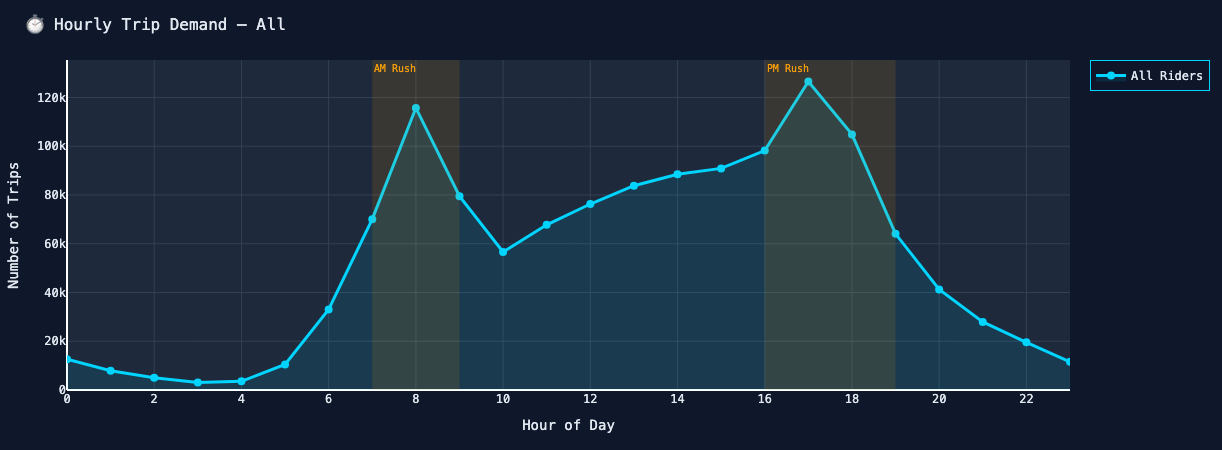

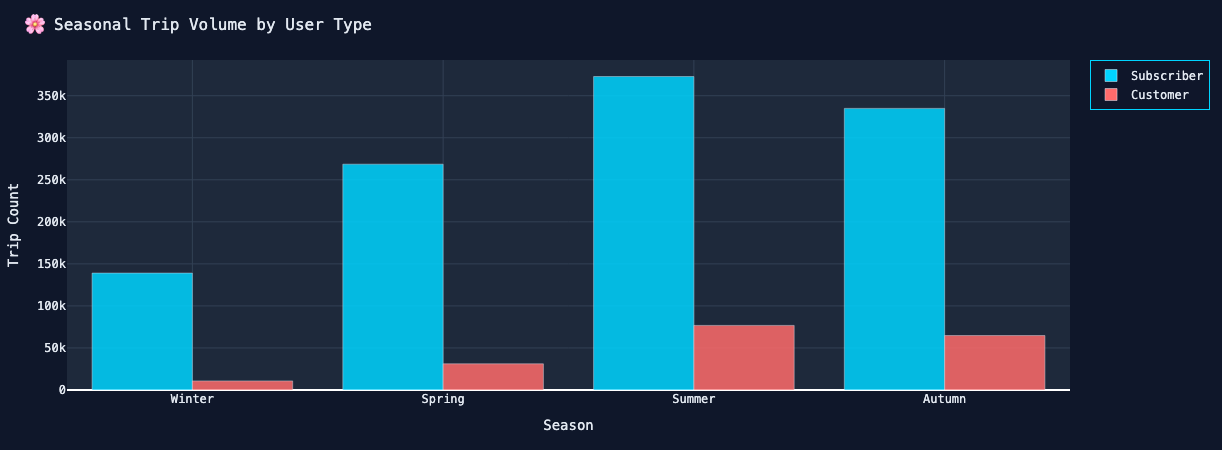

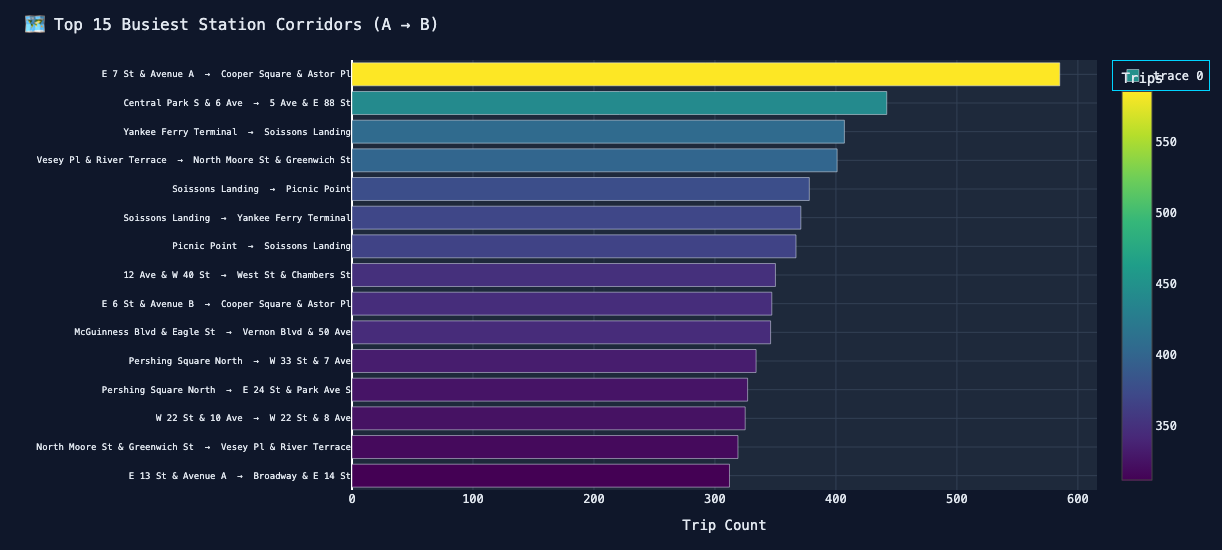

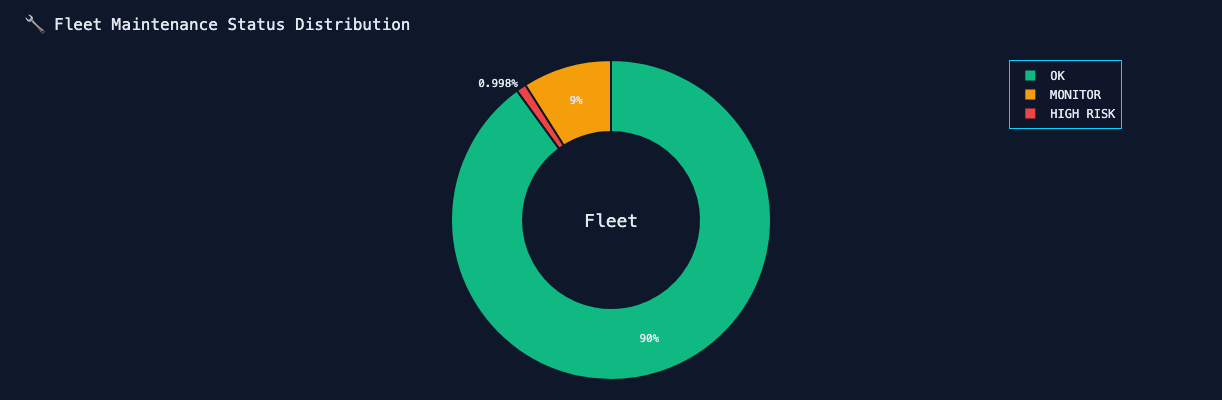

###Installing Dependancies, Global color palette, Shared layout template

In [91]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display, HTML
import pandas as pd
import numpy as np

# ── Global color palette ──────────────────────────────────────────────────────
# A consistent, professional dark-themed palette used across all charts.
COLORS = {
    "primary"    : "#00D4FF",   # cyan
    "secondary"  : "#FF6B6B",   # coral/red
    "accent1"    : "#7C3AED",   # purple
    "accent2"    : "#10B981",   # green
    "accent3"    : "#F59E0B",   # amber
    "subscriber" : "#00D4FF",
    "customer"   : "#FF6B6B",
    "male"       : "#3B82F6",
    "female"     : "#EC4899",
    "bg"         : "#0F172A",   # dark navy background
    "grid"       : "#1E293B",   # slightly lighter for grid lines
    "text"       : "#E2E8F0",   # light text
}

SEASON_COLORS = {
    "Winter": "#93C5FD",
    "Spring": "#6EE7B7",
    "Summer": "#FDE68A",
    "Autumn": "#FCA5A5"
}

# ── Shared layout template ────────────────────────────────────────────────────
def dark_layout(title, height=450, showlegend=True):
    """Returns a consistent dark-themed layout dict for all Plotly figures."""
    return dict(
        title=dict(
            text=title,
            font=dict(size=16, color=COLORS["text"], family="monospace"),
            x=0.02
        ),
        paper_bgcolor=COLORS["bg"],
        plot_bgcolor=COLORS["grid"],
        font=dict(color=COLORS["text"], family="monospace"),
        height=height,
        showlegend=showlegend,
        legend=dict(
            bgcolor="rgba(15,23,42,0.8)",
            bordercolor=COLORS["primary"],
            borderwidth=1
        ),
        xaxis=dict(gridcolor="#334155", zerolinecolor="#334155"),
        yaxis=dict(gridcolor="#334155", zerolinecolor="#334155"),
        margin=dict(l=60, r=20, t=60, b=60)
    )

print("✅ Libraries imported. Starting data collection from Spark...")

✅ Libraries imported. Starting data collection from Spark...


###Data Collection - **D1** to **D11**

In [92]:
# All data for the dashboard is collected from Spark queries here, once.
print("Collecting data for dashboard (may take ~30 sec)...")

# D1: Hourly demand by user type
pd_hourly = spark.sql("""
    SELECT
        start_hour,
        user_type,
        COUNT(*) AS trip_count
    FROM citibike
    GROUP BY start_hour, user_type
    ORDER BY start_hour, user_type
""").toPandas()

# D2: Weekday vs Weekend by user type
pd_daytype = spark.sql("""
    SELECT
        day_type,
        user_type,
        COUNT(*)                            AS trip_count,
        ROUND(AVG(trip_duration_sec)/60, 2) AS avg_duration_min,
        ROUND(AVG(trip_distance_km), 3)     AS avg_distance_km,
        ROUND(AVG(trip_speed_kmh), 2)       AS avg_speed_kmh
    FROM citibike
    GROUP BY day_type, user_type
    ORDER BY day_type, user_type
""").toPandas()

# D3: Seasonal variation
pd_seasonal = spark.sql("""
    SELECT
        season,
        user_type,
        COUNT(*)                            AS trip_count,
        ROUND(AVG(trip_duration_sec)/60, 2) AS avg_duration_min,
        ROUND(AVG(trip_speed_kmh), 2)       AS avg_speed_kmh
    FROM citibike
    GROUP BY season, user_type
    ORDER BY
        CASE season WHEN 'Winter' THEN 1 WHEN 'Spring' THEN 2
                    WHEN 'Summer' THEN 3 ELSE 4 END,
        user_type
""").toPandas()

# D4: Top 15 start stations
pd_stations = spark.sql("""
    SELECT
        start_station_name,
        user_type,
        COUNT(*) AS trip_count
    FROM citibike
    GROUP BY start_station_name, user_type
    ORDER BY trip_count DESC
""").toPandas()

# Top 15 overall for station bar chart
top15_stations = pd_stations.groupby("start_station_name")["trip_count"] \
    .sum().nlargest(15).reset_index()

# D5: Top 15 station corridors
pd_corridors = spark.sql("""
    SELECT
        CONCAT(start_station_name, '  →  ', end_station_name) AS corridor,
        COUNT(*) AS trip_count
    FROM citibike
    WHERE start_station_name <> end_station_name
      AND start_station_name IS NOT NULL
      AND end_station_name IS NOT NULL
    GROUP BY start_station_name, end_station_name
    ORDER BY trip_count DESC
    LIMIT 15
""").toPandas()

# D6: Trip duration by age group
pd_agegroup = spark.sql("""
    SELECT
        age_group,
        ROUND(AVG(trip_duration_sec)/60, 2)    AS avg_duration_min,
        ROUND(MIN(trip_duration_sec)/60, 2)    AS min_duration_min,
        ROUND(MAX(trip_duration_sec)/60, 2)    AS max_duration_min,
        ROUND(STDDEV(trip_duration_sec)/60, 2) AS stddev_duration_min,
        COUNT(*)                               AS trip_count
    FROM citibike
    WHERE age_group IS NOT NULL
    GROUP BY age_group
    ORDER BY age_group
""").toPandas()

# D7: Gender riding behavior
pd_gender = spark.sql("""
    SELECT
        CASE gender WHEN 1 THEN 'Male' WHEN 2 THEN 'Female' END AS gender_label,
        COUNT(*)                                AS trip_count,
        ROUND(AVG(trip_speed_kmh), 2)           AS avg_speed_kmh,
        ROUND(AVG(trip_duration_sec)/60, 2)     AS avg_duration_min,
        ROUND(AVG(trip_distance_km), 3)         AS avg_distance_km
    FROM citibike
    WHERE gender IN (1, 2)
    GROUP BY gender
    ORDER BY gender
""").toPandas()

# D8: User type overview
pd_usertype = spark.sql("""
    SELECT
        user_type,
        COUNT(*)                            AS trip_count,
        ROUND(AVG(trip_duration_sec)/60, 2) AS avg_duration_min,
        ROUND(AVG(trip_distance_km), 3)     AS avg_distance_km,
        ROUND(AVG(trip_speed_kmh), 2)       AS avg_speed_kmh
    FROM citibike
    GROUP BY user_type
""").toPandas()

# D9: Bike utilization
pd_bikes = df_f.toPandas()
pd_bikes_top20 = pd_bikes.head(20)

# D10: Maintenance flag distribution
pd_maint = pd_bikes.groupby("maintenance_flag")["bike_id"] \
    .count().reset_index(name="bike_count")

# D11: Period of day distribution
pd_period = spark.sql("""
    SELECT
        period_of_day,
        user_type,
        COUNT(*) AS trip_count
    FROM citibike
    GROUP BY period_of_day, user_type
    ORDER BY period_of_day, user_type
""").toPandas()

print("All data collected. Building dashboard...")

⏳ Collecting data for dashboard (may take ~30 sec)...
All data collected. Building dashboard...


###Creating The Charts -  **Chart1** to **Chart10**

In [93]:
# Chart 1: Hourly Demand (interactive filter: user_type)
def make_hourly_chart(user_type_filter="All"):
    """
    Creates the hourly demand line chart.
    user_type_filter: "All", "Subscriber", or "Customer"
    """
    if user_type_filter == "All":
        df_plot = pd_hourly.groupby("start_hour")["trip_count"].sum().reset_index()
        color   = COLORS["primary"]
        name    = "All Riders"
        fig     = go.Figure()
        fig.add_trace(go.Scatter(
            x=df_plot["start_hour"], y=df_plot["trip_count"],
            mode="lines+markers",
            line=dict(color=color, width=3),
            marker=dict(size=8, color=color, symbol="circle"),
            fill="tozeroy", fillcolor="rgba(0,212,255,0.1)",
            name=name, hovertemplate="Hour %{x}:00<br>Trips: %{y:,}<extra></extra>"
        ))
    else:
        df_plot = pd_hourly[pd_hourly["user_type"] == user_type_filter]
        color   = COLORS["subscriber"] if user_type_filter == "Subscriber" else COLORS["customer"]
        fig     = go.Figure()
        fig.add_trace(go.Scatter(
            x=df_plot["start_hour"], y=df_plot["trip_count"],
            mode="lines+markers",
            line=dict(color=color, width=3),
            marker=dict(size=8, color=color),
            fill="tozeroy", fillcolor=f"rgba({'0,212,255' if user_type_filter=='Subscriber' else '255,107,107'},0.1)",
            name=user_type_filter,
            hovertemplate="Hour %{x}:00<br>Trips: %{y:,}<extra></extra>"
        ))

    layout = dark_layout(f"⏱ Hourly Trip Demand — {user_type_filter}")
    layout.update(dict(
        xaxis=dict(
            title="Hour of Day", tickmode="linear", dtick=2,
            gridcolor="#334155", tickvals=list(range(0, 24, 2))
        ),
        yaxis=dict(title="Number of Trips", gridcolor="#334155")
    ))
    fig.update_layout(**layout)
    # Add rush hour annotations
    fig.add_vrect(x0=7, x1=9, fillcolor="rgba(245,158,11,0.12)",
                  line_width=0, annotation_text="AM Rush", annotation_position="top left",
                  annotation_font=dict(color=COLORS["accent3"], size=10))
    fig.add_vrect(x0=16, x1=19, fillcolor="rgba(245,158,11,0.12)",
                  line_width=0, annotation_text="PM Rush", annotation_position="top left",
                  annotation_font=dict(color=COLORS["accent3"], size=10))
    return fig

In [94]:
# ── Chart 2: Seasonal Variation ───────────────────────────────────────────────
def make_seasonal_chart():
    """Grouped bar chart: trips per season broken down by user type."""
    season_order = ["Winter", "Spring", "Summer", "Autumn"]
    fig = go.Figure()

    for utype, color in [("Subscriber", COLORS["subscriber"]),
                          ("Customer",   COLORS["customer"])]:
        df_plot = pd_seasonal[pd_seasonal["user_type"] == utype].copy()
        df_plot["season"] = pd.Categorical(df_plot["season"], categories=season_order, ordered=True)
        df_plot = df_plot.sort_values("season")
        fig.add_trace(go.Bar(
            x=df_plot["season"],
            y=df_plot["trip_count"],
            name=utype,
            marker=dict(color=color, opacity=0.85),
            hovertemplate="%{x}<br>%{y:,} trips<extra>" + utype + "</extra>"
        ))

    layout = dark_layout("🌸 Seasonal Trip Volume by User Type")
    layout.update(dict(
        barmode="group",
        xaxis=dict(title="Season", gridcolor="#334155"),
        yaxis=dict(title="Trip Count", gridcolor="#334155")
    ))
    fig.update_layout(**layout)
    return fig

In [95]:
# ── Chart 3: Weekday vs Weekend comparison ───────────────────────────────────
def make_daytype_chart():
    """Side-by-side metrics comparison: weekday vs weekend."""
    metrics  = ["avg_duration_min", "avg_distance_km", "avg_speed_kmh"]
    labels   = ["Avg Duration (min)", "Avg Distance (km)", "Avg Speed (km/h)"]

    fig = make_subplots(
        rows=1, cols=3,
        subplot_titles=labels,
        horizontal_spacing=0.08
    )

    day_types = ["Weekday", "Weekend"]
    day_colors = [COLORS["primary"], COLORS["secondary"]]

    for col_idx, (metric, label) in enumerate(zip(metrics, labels)):
        totals = pd_daytype.groupby("day_type")[metric].mean().reindex(day_types)
        fig.add_trace(
            go.Bar(
                x=day_types,
                y=totals.values,
                name=label,
                marker=dict(color=day_colors, opacity=0.85),
                showlegend=False,
                hovertemplate="%{x}<br>" + label + ": %{y:.2f}<extra></extra>"
            ),
            row=1, col=col_idx + 1
        )

    layout = dark_layout("📅 Weekday vs Weekend Riding Behavior", height=380)
    layout.pop("xaxis", None)
    layout.pop("yaxis", None)
    fig.update_layout(
        paper_bgcolor=COLORS["bg"],
        plot_bgcolor=COLORS["grid"],
        font=dict(color=COLORS["text"], family="monospace"),
        height=380,
        showlegend=False,
        title=dict(
            text="📅 Weekday vs Weekend Riding Behavior",
            font=dict(size=16, color=COLORS["text"]),
            x=0.02
        ),
        margin=dict(l=60, r=20, t=60, b=60)
    )
    for i in range(1, 4):
        fig.update_xaxes(gridcolor="#334155", row=1, col=i)
        fig.update_yaxes(gridcolor="#334155", row=1, col=i)
    return fig

In [96]:
# ── Chart 4: Top 15 Start Stations ───────────────────────────────────────────
def make_stations_chart():
    """Horizontal bar chart of top 15 start stations by total trip count."""
    df_plot = top15_stations.sort_values("trip_count", ascending=True)

    # Color bars by volume intensity
    norm   = df_plot["trip_count"] / df_plot["trip_count"].max()
    colors = [f"rgba(0,{int(100+155*v)},{int(200+55*v)},0.85)" for v in norm]

    fig = go.Figure(go.Bar(
        x=df_plot["trip_count"],
        y=df_plot["start_station_name"],
        orientation="h",
        marker=dict(color=colors),
        hovertemplate="%{y}<br>Trips: %{x:,}<extra></extra>",
        text=df_plot["trip_count"].apply(lambda x: f"{x:,}"),
        textposition="outside",
        textfont=dict(color=COLORS["text"], size=10)
    ))

    layout = dark_layout("📍 Top 15 Most Popular Start Stations", height=520)
    layout.update(dict(
        xaxis=dict(title="Trip Count", gridcolor="#334155"),
        yaxis=dict(title="", gridcolor="#334155", tickfont=dict(size=10))
    ))
    fig.update_layout(**layout)
    return fig

In [97]:
# ── Chart 5: Top 15 Station Corridors ────────────────────────────────────────
def make_corridors_chart():
    """Horizontal bar: busiest A→B corridors."""
    df_plot = pd_corridors.sort_values("trip_count", ascending=True)

    fig = go.Figure(go.Bar(
        x=df_plot["trip_count"],
        y=df_plot["corridor"],
        orientation="h",
        marker=dict(
            color=df_plot["trip_count"],
            colorscale="Viridis",
            showscale=True,
            colorbar=dict(
                title="Trips",
                tickfont=dict(color=COLORS["text"]),
                titlefont=dict(color=COLORS["text"])
            )
        ),
        hovertemplate="%{y}<br>Trips: %{x:,}<extra></extra>"
    ))

    layout = dark_layout("🗺 Top 15 Busiest Station Corridors (A → B)", height=550)
    layout.update(dict(
        xaxis=dict(title="Trip Count", gridcolor="#334155"),
        yaxis=dict(title="", gridcolor="#334155", tickfont=dict(size=9))
    ))
    fig.update_layout(**layout)
    return fig

In [98]:
# ── Chart 6: Trip Duration by Age Group ──────────────────────────────────────
def make_agegroup_chart():
    """
    Bar chart with error bars showing avg trip duration per age group.
    Error bars = ± 1 standard deviation (shows spread within each group).
    """
    df_plot     = pd_agegroup.sort_values("age_group")
    age_colors  = [COLORS["accent2"], COLORS["primary"], COLORS["accent3"]]

    fig = go.Figure()
    for i, row in df_plot.iterrows():
        fig.add_trace(go.Bar(
            x=[row["age_group"]],
            y=[row["avg_duration_min"]],
            error_y=dict(
                type="data",
                array=[min(row["stddev_duration_min"], row["avg_duration_min"] * 0.8)],
                color=COLORS["text"],
                thickness=2,
                width=8
            ),
            name=row["age_group"],
            marker=dict(color=age_colors[i % 3], opacity=0.85),
            hovertemplate=(
                f"<b>{row['age_group']}</b><br>"
                f"Avg Duration: {row['avg_duration_min']} min<br>"
                f"Std Dev: {row['stddev_duration_min']} min<br>"
                f"Trips: {row['trip_count']:,}<extra></extra>"
            )
        ))

    layout = dark_layout("👤 Avg Trip Duration by Age Group (± 1 std dev)")
    layout.update(dict(
        xaxis=dict(title="Age Group", gridcolor="#334155"),
        yaxis=dict(title="Avg Duration (minutes)", gridcolor="#334155"),
        showlegend=False
    ))
    fig.update_layout(**layout)
    return fig

In [99]:
# ── Chart 7: Gender Riding Patterns ──────────────────────────────────────────
def make_gender_chart():
    """
    Radar/spider chart comparing Male vs Female across three metrics:
    avg speed, avg duration, avg distance (normalized 0–1 for comparison).
    """
    categories  = ["Avg Speed (km/h)", "Avg Duration (min)", "Avg Distance (km)"]

    # Normalize each metric to 0–1 range for radar comparison
    metrics     = ["avg_speed_kmh", "avg_duration_min", "avg_distance_km"]
    male_vals   = pd_gender[pd_gender["gender_label"] == "Male"][metrics].values[0]
    female_vals = pd_gender[pd_gender["gender_label"] == "Female"][metrics].values[0]

    # Normalize
    combined    = np.vstack([male_vals, female_vals])
    col_max     = combined.max(axis=0)
    col_max[col_max == 0] = 1
    male_norm   = male_vals / col_max
    female_norm = female_vals / col_max

    fig = go.Figure()

    for vals, norm_vals, label, color in [
        (male_vals, male_norm, "Male", COLORS["male"]),
        (female_vals, female_norm, "Female", COLORS["female"])
    ]:
        fig.add_trace(go.Scatterpolar(
            r=np.append(norm_vals, norm_vals[0]),
            theta=categories + [categories[0]],
            fill="toself",
            fillcolor=color.replace("#", "rgba(").replace("3B82F6", "59,130,246,0.2)")
                        .replace("EC4899", "236,72,153,0.2)"),
            line=dict(color=color, width=2),
            name=label,
            hovertemplate=(
                "<b>" + label + "</b><br>" +
                "Speed: " + str(round(vals[0], 2)) + " km/h<br>" +
                "Duration: " + str(round(vals[1], 2)) + " min<br>" +
                "Distance: " + str(round(vals[2], 3)) + " km<extra></extra>"
            )
        ))

    fig.update_layout(
        polar=dict(
            bgcolor=COLORS["grid"],
            radialaxis=dict(
                visible=True, range=[0, 1],
                gridcolor="#334155", color=COLORS["text"]
            ),
            angularaxis=dict(gridcolor="#334155", color=COLORS["text"])
        ),
        paper_bgcolor=COLORS["bg"],
        font=dict(color=COLORS["text"], family="monospace"),
        title=dict(
            text="♂♀ Gender Riding Behavior Comparison (normalized)",
            font=dict(size=16, color=COLORS["text"]), x=0.02
        ),
        legend=dict(bgcolor="rgba(15,23,42,0.8)", bordercolor=COLORS["primary"],
                    borderwidth=1),
        height=430, margin=dict(l=60, r=60, t=60, b=40)
    )
    return fig

In [100]:
# ── Chart 8: User Type Metrics ────────────────────────────────────────────────
def make_usertype_chart():
    """Grouped horizontal bar: Subscriber vs Customer on 3 key metrics."""
    metrics  = ["avg_duration_min", "avg_distance_km", "avg_speed_kmh"]
    labels   = ["Avg Duration (min)", "Avg Distance (km)", "Avg Speed (km/h)"]

    sub_row = pd_usertype[pd_usertype["user_type"] == "Subscriber"].iloc[0]
    cus_row = pd_usertype[pd_usertype["user_type"] == "Customer"].iloc[0]

    fig = go.Figure()
    for metric, label in zip(metrics, labels):
        fig.add_trace(go.Bar(
            y=[label],
            x=[sub_row[metric]],
            orientation="h",
            name="Subscriber",
            marker=dict(color=COLORS["subscriber"], opacity=0.85),
            legendgroup="Subscriber",
            showlegend=(metric == metrics[0]),
            hovertemplate=f"Subscriber<br>{label}: %{{x:.2f}}<extra></extra>"
        ))
        fig.add_trace(go.Bar(
            y=[label],
            x=[cus_row[metric]],
            orientation="h",
            name="Customer",
            marker=dict(color=COLORS["customer"], opacity=0.85),
            legendgroup="Customer",
            showlegend=(metric == metrics[0]),
            hovertemplate=f"Customer<br>{label}: %{{x:.2f}}<extra></extra>"
        ))

    layout = dark_layout("🎟 Subscriber vs Customer — Key Metrics", height=380)
    layout.update(dict(
        barmode="group",
        xaxis=dict(title="Value", gridcolor="#334155"),
        yaxis=dict(title="", gridcolor="#334155")
    ))
    fig.update_layout(**layout)
    return fig

In [101]:
# ── Chart 9: Top 20 Overused Bikes ───────────────────────────────────────────
def make_bikes_chart():
    """
    Horizontal bar chart — top 20 bikes by total hours.
    Colored by maintenance_flag: red=HIGH RISK, amber=MONITOR, green=OK.
    """
    df_plot = pd_bikes_top20.sort_values("total_trip_hours", ascending=True)

    flag_color_map = {
        "🔴 HIGH RISK": "#EF4444",
        "🟡 MONITOR"  : "#F59E0B",
        "🟢 OK"        : "#10B981"
    }
    colors = [flag_color_map.get(f, COLORS["primary"])
              for f in df_plot["maintenance_flag"]]

    fig = go.Figure(go.Bar(
        x=df_plot["total_trip_hours"],
        y=df_plot["bike_id"].astype(str),
        orientation="h",
        marker=dict(color=colors, opacity=0.9),
        hovertemplate=(
            "Bike ID: %{y}<br>"
            "Total Hours: %{x:.1f}<br>"
            "<extra></extra>"
        ),
        text=df_plot["total_trip_hours"].apply(lambda x: f"{x:.0f}h"),
        textposition="outside",
        textfont=dict(color=COLORS["text"], size=9)
    ))

    # Add legend manually
    for flag, color in flag_color_map.items():
        fig.add_trace(go.Bar(
            x=[None], y=[None],
            marker=dict(color=color),
            name=flag,
            showlegend=True
        ))

    layout = dark_layout("🚲 Top 20 Most Utilized Bikes (by Total Hours)", height=560)
    layout.update(dict(
        xaxis=dict(title="Total Ride Hours", gridcolor="#334155"),
        yaxis=dict(title="Bike ID", gridcolor="#334155", tickfont=dict(size=9))
    ))
    fig.update_layout(**layout)
    return fig

In [102]:
# ── Chart 10: Maintenance Flag Donut ─────────────────────────────────────────
def make_maint_donut():
    """Donut chart showing fleet breakdown by maintenance status."""
    labels  = pd_maint["maintenance_flag"].str.replace("🔴 ", "").str.replace("🟡 ", "").str.replace("🟢 ", "").tolist()
    values  = pd_maint["bike_count"].tolist()
    colors  = ["#EF4444", "#F59E0B", "#10B981"]

    fig = go.Figure(go.Pie(
        labels=pd_maint["maintenance_flag"].tolist(),
        values=values,
        hole=0.55,
        marker=dict(colors=colors[:len(labels)], line=dict(color=COLORS["bg"], width=2)),
        hovertemplate="%{label}<br>%{value:,} bikes (%{percent})<extra></extra>",
        textfont=dict(color=COLORS["text"], size=11)
    ))

    fig.update_layout(
        paper_bgcolor=COLORS["bg"],
        font=dict(color=COLORS["text"], family="monospace"),
        title=dict(
            text="🔧 Fleet Maintenance Status Distribution",
            font=dict(size=16, color=COLORS["text"]), x=0.02
        ),
        legend=dict(bgcolor="rgba(15,23,42,0.8)", bordercolor=COLORS["primary"],
                    borderwidth=1),
        height=400,
        annotations=[dict(
            text="Fleet",
            x=0.5, y=0.5,
            font=dict(size=18, color=COLORS["text"]),
            showarrow=False
        )],
        margin=dict(l=20, r=20, t=60, b=20)
    )
    return fig

###Interactive Dashboard - **HTML FILE**

In [103]:
# ── Dashboard header HTML ─────────────────────────────────────────────────────
header_html = """
<div style="
    background: linear-gradient(135deg, #0F172A 0%, #1E293B 50%, #0F172A 100%);
    border: 1px solid #00D4FF;
    border-radius: 12px;
    padding: 28px 36px;
    margin-bottom: 20px;
    font-family: monospace;
">
    <h1 style="color:#00D4FF; margin:0 0 8px 0; font-size:26px; letter-spacing:2px;">
        🚴 CITI BIKE ANALYTICS DASHBOARD
    </h1>
    <p style="color:#94A3B8; margin:0; font-size:13px;">
        New York City Bike-Share System · Powered by Apache Spark · Spring 2026
    </p>
    <div style="display:flex; gap:32px; margin-top:18px;">
        <div style="text-align:center;">
            <div style="color:#00D4FF; font-size:22px; font-weight:bold;">
                {:,}
            </div>
            <div style="color:#64748B; font-size:11px;">TOTAL TRIPS</div>
        </div>
        <div style="text-align:center;">
            <div style="color:#7C3AED; font-size:22px; font-weight:bold;">
                {:,}
            </div>
            <div style="color:#64748B; font-size:11px;">UNIQUE BIKES</div>
        </div>
        <div style="text-align:center;">
            <div style="color:#10B981; font-size:22px; font-weight:bold;">
                {:,}
            </div>
            <div style="color:#64748B; font-size:11px;">STATIONS</div>
        </div>
        <div style="text-align:center;">
            <div style="color:#F59E0B; font-size:22px; font-weight:bold;">
                {:,.0f}
            </div>
            <div style="color:#64748B; font-size:11px;">AVG DAILY TRIPS</div>
        </div>
    </div>
</div>
""".format(
    df_clean.count(),
    df_clean.select("bike_id").distinct().count(),
    df_clean.select("start_station_name").distinct().count(),
    df_clean.count() / 365
)


# ── Section header helper ─────────────────────────────────────────────────────
def section_header(icon, title, color="#00D4FF"):
    display(HTML(f"""
    <div style="
        border-left: 4px solid {color};
        padding: 8px 16px;
        margin: 24px 0 12px 0;
        background: rgba(30,41,59,0.5);
        border-radius: 0 8px 8px 0;
        font-family: monospace;
    ">
        <span style="color:{color}; font-size:18px; font-weight:bold;">
            {icon} {title}
        </span>
    </div>
    """))


# ── Interactive filter widget ─────────────────────────────────────────────────
user_type_dropdown = widgets.Dropdown(
    options=["All", "Subscriber", "Customer"],
    value="All",
    description="👤 User Type:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="260px")
)

style_html = """
<style>
    .widget-label { color: #E2E8F0 !important; font-family: monospace; }
    .widget-dropdown select {
        background-color: #1E293B !important;
        color: #00D4FF !important;
        border: 1px solid #00D4FF !important;
        border-radius: 6px;
        font-family: monospace;
    }
</style>
"""
display(HTML(style_html))


# ── Main render function — called on every widget change ──────────────────────
def render_dashboard(user_type):
    """Renders the full dashboard, re-drawing the interactive chart on filter change."""
    from IPython.display import clear_output

    # Clear and re-render
    clear_output(wait=True)
    display(HTML(style_html))
    display(HTML(header_html))
    display(user_type_dropdown)

    # ── SECTION 1: TEMPORAL ──────────────────────────────────────────────────
    section_header("⏱", "TEMPORAL ANALYSIS", COLORS["primary"])
    make_hourly_chart(user_type).show()        # interactive filter applied here

    # Side-by-side: seasonal + weekday/weekend
    col1, col2 = widgets.Output(), widgets.Output()
    with col1: make_seasonal_chart().show()
    with col2: make_daytype_chart().show()
    display(widgets.HBox([col1, col2]))

    # ── SECTION 2: STATION ───────────────────────────────────────────────────
    section_header("📍", "STATION ANALYSIS", COLORS["accent1"])
    make_stations_chart().show()
    make_corridors_chart().show()

    # ── SECTION 3: USER BEHAVIOR ─────────────────────────────────────────────
    section_header("👤", "USER BEHAVIOR", COLORS["accent2"])
    col3, col4 = widgets.Output(), widgets.Output()
    with col3: make_agegroup_chart().show()
    with col4: make_gender_chart().show()
    display(widgets.HBox([col3, col4]))
    make_usertype_chart().show()

    # ── SECTION 4: BIKE UTILIZATION ──────────────────────────────────────────
    section_header("🚲", "BIKE UTILIZATION", COLORS["accent3"])
    col5, col6 = widgets.Output(), widgets.Output()
    with col5: make_bikes_chart().show()
    with col6: make_maint_donut().show()
    display(widgets.HBox([col5, col6]))

    display(HTML("""
    <div style="text-align:center; color:#475569; font-family:monospace;
                font-size:11px; margin-top:24px; padding:12px;
                border-top:1px solid #1E293B;">
        Citi Bike Analytics Dashboard · German International University ·
        Big Data & NoSQL Databases · Spring 2026
    </div>
    """))


# ── Connect widget to render function ─────────────────────────────────────────
widgets.interactive_output(
    render_dashboard,
    {"user_type": user_type_dropdown}
)

# ── Initial render ────────────────────────────────────────────────────────────
display(HTML(header_html))
display(user_type_dropdown)
widgets.interactive_output(render_dashboard, {"user_type": user_type_dropdown})
render_dashboard("All")


# -— Save the full dashboard as a self-contained HTML file ─────────────────────
# This creates a single .html file you can open in any browser or share
import plotly.io as pio
from pathlib import Path

def export_dashboard_html():
    """Exports all charts to a single HTML file."""
    charts = [
        make_hourly_chart("All"),
        make_hourly_chart("Subscriber"),
        make_hourly_chart("Customer"),
        make_seasonal_chart(),
        make_daytype_chart(),
        make_stations_chart(),
        make_corridors_chart(),
        make_agegroup_chart(),
        make_gender_chart(),
        make_usertype_chart(),
        make_bikes_chart(),
        make_maint_donut(),
    ]

    chart_titles = [
        "Hourly Demand — All", "Hourly Demand — Subscribers",
        "Hourly Demand — Customers", "Seasonal Variation",
        "Weekday vs Weekend", "Top 15 Start Stations",
        "Top 15 Corridors", "Duration by Age Group",
        "Gender Comparison", "Subscriber vs Customer",
        "Top 20 Overused Bikes", "Maintenance Status"
    ]

    html_parts = ["""
    <html><head>
    <meta charset="utf-8">
    <title>Citi Bike Dashboard</title>
    <style>
        body { background:#0F172A; margin:0; padding:20px;
               font-family:monospace; }
        h1   { color:#00D4FF; text-align:center; letter-spacing:3px; }
        h2   { color:#94A3B8; font-size:13px; text-align:center; margin-top:0; }
        .chart-wrap { background:#1E293B; border-radius:10px;
                      margin:16px 0; padding:8px;
                      border:1px solid #334155; }
    </style>
    </head><body>
    <h1>🚴 CITI BIKE ANALYTICS DASHBOARD</h1>
    <h2>German International University · Big Data & NoSQL · Spring 2026</h2>
    """]

    for fig, title in zip(charts, chart_titles):
        html_parts.append(f'<div class="chart-wrap">')
        html_parts.append(pio.to_html(fig, full_html=False, include_plotlyjs="cdn"))
        html_parts.append("</div>")

    html_parts.append("</body></html>")
    full_html = "\n".join(html_parts)

    output_path = "/content/drive/MyDrive/citibike_dashboard.html"
    Path(output_path).write_text(full_html, encoding="utf-8")
    print(f"Dashboard exported to: {output_path}")
    print("Open this file in any browser to view the interactive charts.")

export_dashboard_html()


Dropdown(description='👤 User Type:', layout=Layout(width='260px'), options=('All', 'Subscriber', 'Customer'), …

✅ Dashboard exported to: /content/drive/MyDrive/citibike_dashboard.html
   Open this file in any browser to view the interactive charts.

✅ PART 5 COMPLETE.
